# Tech Challenge - Olist
## Caderno de Estudo, Análise de Dados e Relatório Executivo

Este notebook foi construído com dois objetivos principais.

O primeiro objetivo é servir como material de estudo em Python e análise de dados, mostrando passo a passo como transformar arquivos brutos em uma análise estruturada.

O segundo objetivo é servir como base para o relatório executivo do Tech Challenge, conectando os resultados encontrados a uma narrativa de negócio voltada para investidores e tomadores de decisão.

Ao longo deste caderno, a análise será organizada em etapas progressivas:
1. leitura e entendimento dos dados
2. construção da base analítica
3. cálculo dos principais indicadores
4. visualização dos resultados
5. interpretação executiva
6. conclusões e recomendações

A proposta é não apenas rodar código, mas entender o que cada etapa gera e por que ela importa para o negócio.

## 1. Importação das bibliotecas

Nesta etapa, vamos importar as bibliotecas principais que serão utilizadas ao longo da análise.

A biblioteca `pandas` será usada para leitura, organização e transformação dos dados em tabelas.

A biblioteca `matplotlib.pyplot` será usada para criar gráficos.

A biblioteca `seaborn` será usada para melhorar a aparência visual dos gráficos e facilitar algumas visualizações.

A classe `Path`, da biblioteca `pathlib`, será usada para trabalhar com caminhos de arquivos e pastas de forma mais segura e organizada.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Definição do caminho dos arquivos

Agora vamos definir a pasta onde estão armazenados os arquivos do projeto.

Também vamos criar uma pasta de saída, onde poderão ser salvos gráficos, tabelas e arquivos auxiliares produzidos ao longo da análise.

Isso é importante para manter o projeto organizado e facilitar a reprodutibilidade.

O que esta etapa gera
Esse bloco mostra:

a pasta principal do projeto
a pasta de saída da análise
Além disso, ele cria automaticamente a pasta outputs_analise_olist, caso ela ainda não exista.

Leitura para estudo
Aqui você aprende uma prática muito boa de projeto: não deixar tudo solto na mesma pasta.

Leitura para o relatório
Isso fortalece a parte de governança e reprodutibilidade, que o enunciado valoriza.

In [2]:
BASE_DIR = Path(r"C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng")
OUTPUT_DIR = BASE_DIR / "outputs_analise_olist"
OUTPUT_DIR.mkdir(exist_ok=True)

print(BASE_DIR)
print(OUTPUT_DIR)

C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng
C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist


## 3. Configuração visual dos gráficos

Antes de gerar qualquer visualização, vamos definir um estilo padrão para os gráficos.

Isso ajuda a manter consistência visual ao longo do notebook e melhora a apresentação dos resultados.

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 4. Leitura dos arquivos principais

Agora vamos carregar os arquivos mais importantes do dataset da Olist.

Os arquivos escolhidos para esta primeira fase da análise são:
- pedidos
- itens dos pedidos
- pagamentos
- avaliações
- clientes
- produtos
- tradução das categorias

Algumas colunas de data serão convertidas automaticamente para o formato de data, o que facilitará análises temporais e cálculos de prazo.

O que esta etapa gera
Esse bloco cria os principais DataFrames da análise:

orders_df
order_items_df
payments_df
reviews_df
customers_df
products_df
translation_df
Leitura para estudo
Um DataFrame é a estrutura central do pandas.
Você pode pensar nele como uma tabela com linhas e colunas, parecida com uma planilha.

Leitura para o relatório
Essa é a base metodológica do projeto. A análise executiva será construída a partir da integração dessas tabelas.

In [4]:
orders_df = pd.read_csv(
    BASE_DIR / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

order_items_df = pd.read_csv(
    BASE_DIR / "olist_order_items_dataset.csv",
    parse_dates=["shipping_limit_date"]
)

payments_df = pd.read_csv(BASE_DIR / "olist_order_payments_dataset.csv")

reviews_df = pd.read_csv(
    BASE_DIR / "olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"]
)

customers_df = pd.read_csv(BASE_DIR / "olist_customers_dataset.csv")
products_df = pd.read_csv(BASE_DIR / "olist_products_dataset.csv")
translation_df = pd.read_csv(BASE_DIR / "product_category_name_translation.csv")

## 5. Conferência inicial da leitura dos arquivos

Antes de avançar, é importante verificar se os arquivos foram carregados corretamente.

Vamos observar as primeiras linhas de algumas tabelas e também suas dimensões.

In [5]:
print(orders_df.head())
print(order_items_df.head())
print(payments_df.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39 2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15

In [6]:
print(orders_df.shape)
print(order_items_df.shape)
print(payments_df.shape)
print(reviews_df.shape)
print(customers_df.shape)
print(products_df.shape)
print(translation_df.shape)

(99441, 8)
(112650, 7)
(103886, 5)
(99224, 7)
(99441, 5)
(32951, 9)
(71, 2)


O que esta etapa gera
Você vai ver:

as primeiras linhas das tabelas
a quantidade de linhas e colunas de cada arquivo
Leitura para estudo
Esse passo é essencial para validar se:

os arquivos certos foram lidos
as colunas esperadas estão presentes
o volume dos dados parece coerente
Leitura para o relatório
Isso ajuda na seção de entendimento e documentação da base, mas normalmente não vai inteiro para a versão final.
No notebook, porém, é ótimo manter.

## 6. Primeiras observações sobre a estrutura da base

A tabela de pedidos será o eixo central da análise, porque ela conecta clientes, datas, status de entrega e outros eventos importantes da jornada de compra.

A tabela de itens complementa os pedidos com informações de preço, frete, produto e seller.

A tabela de pagamentos mostra como o pedido foi pago.

A tabela de avaliações conecta a experiência do cliente ao pedido realizado.

A tabela de clientes permite análises geográficas, como estado e cidade do comprador.

A tabela de produtos, junto com a tradução das categorias, ajuda a identificar quais tipos de produto geram mais receita.

## 7. Consideração executiva desta etapa

Até aqui, ainda não estamos apresentando resultados de negócio, mas sim preparando a base analítica.

Do ponto de vista executivo, esta etapa é importante porque mostra que a análise será construída sobre múltiplas dimensões do negócio:
- comercial
- logística
- comportamento de pagamento
- experiência do cliente
- geografia

Essa visão integrada será essencial para produzir um relatório realmente útil para decisão.

## 8. Entendendo melhor a estrutura das tabelas

Agora que os arquivos já foram carregados, vamos aprofundar o entendimento da estrutura de cada tabela.

Nesta etapa, o objetivo não é ainda analisar performance do negócio, mas entender:
- quais colunas existem
- que tipo de informação cada tabela guarda
- como as tabelas poderão se conectar mais adiante

Esse passo é muito importante porque uma boa análise começa com uma boa leitura da estrutura dos dados.

In [7]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


O que esta etapa gera
Esse comando mostra:

os nomes das colunas
quantas linhas não nulas existem em cada uma
o tipo de dado de cada coluna
Leitura para estudo
O método .info() é uma das formas mais úteis de inspecionar um DataFrame, porque ele permite ver rapidamente:

se existem valores ausentes
quais colunas são datas, textos ou números
se a leitura do arquivo parece correta
Leitura para o relatório
Aqui você começa a perceber que a tabela de pedidos é central para o projeto, porque ela reúne:

identificação do pedido
status
datas de compra
datas de aprovação
datas de entrega
data estimada
Essas colunas serão fundamentais para a análise de crescimento e logística.

## 9. Visualizando uma amostra da tabela de pedidos

Depois de olhar a estrutura, também é útil observar algumas linhas reais da base para entender o conteúdo das colunas.


In [8]:
orders_df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23


O que esta etapa gera
Mostra as 10 primeiras linhas da tabela de pedidos.

Leitura para estudo
Aqui você consegue enxergar melhor a jornada do pedido:

momento da compra
aprovação do pagamento
envio ao transportador
entrega ao cliente
prazo estimado
Leitura para o relatório
Essa tabela já mostra, de forma implícita, que existe uma trilha operacional completa que poderá ser transformada em indicadores de prazo e eficiência.



## 10. Entendendo a tabela de itens dos pedidos

Agora vamos analisar a tabela de itens.

Essa tabela é essencial porque cada pedido pode conter um ou mais produtos. É nela que estão os valores de preço e frete, que serão usados para calcular receita e ticket médio.

In [9]:
order_items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


In [10]:
order_items_df.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


O que esta etapa gera
Esses blocos mostram a estrutura e uma amostra da tabela de itens.

Leitura para estudo
Aqui você verá colunas como:

order_id
order_item_id
product_id
seller_id
price
freight_value
Isso mostra que a tabela de itens é a fonte principal para monetização da análise.

Leitura para o relatório
Sem essa tabela, não seria possível calcular:

receita por pedido
receita por categoria
receita por seller
ticket médio


## 11. Entendendo a tabela de pagamentos

A tabela de pagamentos mostra como os clientes pagaram pelos pedidos.

Ela é importante para complementar a visão comercial e entender o comportamento transacional da base.

In [11]:
payments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [12]:
payments_df.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


O que esta etapa gera
Mostra a estrutura da tabela de pagamentos e uma amostra dos registros.

Leitura para estudo
Aqui aparecem informações como:

tipo de pagamento
número de parcelas
valor do pagamento
Leitura para o relatório
Essa tabela vai ajudar a responder perguntas como:

qual é o meio de pagamento dominante
quanto cada meio movimenta em valor
se o comportamento de pagamento sugere uso intenso de crédito e parcelamento

## 12. Entendendo a tabela de avaliações

As avaliações conectam a operação à percepção do cliente.

Essa tabela será muito importante porque permitirá avaliar se problemas logísticos, como atraso, afetam diretamente a satisfação.

In [13]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  str           
 4   review_comment_message   40977 non-null  str           
 5   review_creation_date     99224 non-null  datetime64[us]
 6   review_answer_timestamp  99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 5.3 MB


In [14]:
reviews_df.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22,2018-05-23 16:45:47


O que esta etapa gera
Mostra a estrutura da tabela de avaliações e as primeiras linhas da base.

Leitura para estudo
A coluna mais importante aqui, neste primeiro momento, é a review_score.

Leitura para o relatório
Essa é a ponte entre operação e experiência do cliente, um dos pontos mais fortes do relatório executivo.

## 13. Entendendo clientes, produtos e tradução de categorias

Agora vamos observar as tabelas auxiliares que enriquecem a análise.

A tabela de clientes permite olhar estados e cidades.

A tabela de produtos permite identificar o tipo de produto vendido.

A tabela de tradução ajuda a tornar os nomes de categoria mais legíveis.

In [15]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [16]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [17]:
translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


O que esta etapa gera
Esses blocos mostram amostras das tabelas de clientes, produtos e tradução.

Leitura para estudo
Você começa a enxergar como cada tabela vai enriquecer a análise principal.

Leitura para o relatório
Essas tabelas serão fundamentais para:

análise regional
análise por categoria
leitura de concentração de valor

## 14. Traduzindo as categorias de produto

O dataset de produtos guarda a categoria em um campo chamado `product_category_name`.

Para facilitar análises futuras, vamos juntar a tabela de tradução e criar uma base de itens com o nome traduzido da categoria.

In [18]:
products_en_df = products_df.merge(
    translation_df,
    on="product_category_name",
    how="left"
)

items_en_df = order_items_df.merge(
    products_en_df[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)

items_en_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools


O que esta etapa gera
Esse bloco cria duas novas tabelas:

products_en_df
items_en_df
A mais importante, neste momento, é a items_en_df, porque ela passa a conter:

o item do pedido
o preço
o frete
a categoria traduzida do produto
Leitura para estudo
Aqui você está usando merge(), que é uma das operações mais importantes do pandas.

Ela funciona como um “PROCV inteligente” entre tabelas.

Leitura para o relatório
Esse passo é decisivo para a futura análise de categorias líderes por receita.

## 15. Calculando a receita total por pedido

Como um pedido pode ter mais de um item, não podemos olhar apenas linha por linha na tabela de itens.

Precisamos agrupar os itens por pedido para calcular:
- a receita total do pedido
- o frete total do pedido

Esse passo será central para os KPIs executivos.

In [19]:
order_value_df = items_en_df.groupby("order_id", as_index=False).agg(
    receita=("price", "sum"),
    frete=("freight_value", "sum")
)

order_value_df.head()

,order_id,receita,frete
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14


O que esta etapa gera
Cria a tabela order_value_df, que resume os pedidos em nível financeiro.

Leitura para estudo
Aqui você aprende uma operação muito importante:
groupby() + agg()

Ela serve para agregar várias linhas em uma visão resumida.

Leitura para o relatório
Essa tabela será a base para:

receita total
ticket médio
receita por estado
receita por mês

## 16. Montando a base analítica principal

Agora vamos juntar as principais dimensões da análise em uma única tabela.

Essa nova base vai reunir:
- informações do pedido
- receita e frete
- localização do cliente
- avaliação do cliente

Ela será a tabela principal do projeto.

In [20]:
base_df = (
    orders_df.merge(order_value_df, on="order_id", how="left")
    .merge(
        customers_df[["customer_id", "customer_state", "customer_city", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
    .merge(
        reviews_df[["order_id", "review_score"]],
        on="order_id",
        how="left"
    )
)

base_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,receita,frete,customer_state,customer_city,customer_unique_id,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,SP,sao paulo,7c396fd4830fd04220f754e42b4e5bff,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,BA,barreiras,af07308b275d755c9edb36a90c618231,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,GO,vianopolis,3a653a41f6f9fc3d2a113cf8398680e8,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,RN,sao goncalo do amarante,7c142cf63193a1473d2e66489a9ae977,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,SP,santo andre,72632f0f9dd73dfee390c9b22eb56dd6,5.0


O que esta etapa gera
Cria a base_df, que passa a ser a principal tabela de análise do projeto.

Leitura para estudo
Essa é uma etapa muito importante, porque agora você deixa de trabalhar com várias tabelas separadas e passa a ter uma base consolidada.

Leitura para o relatório
Essa tabela permite unir três visões fundamentais:

desempenho comercial
eficiência operacional
percepção do cliente

## 17. Criando colunas derivadas para a análise

Agora vamos criar algumas colunas novas que serão muito importantes para os indicadores.

Essas colunas ajudam a transformar dados brutos em métricas analíticas:
- mês da compra
- prazo de entrega em dias
- atraso em relação ao prazo estimado
- indicador de entrega atrasada

In [21]:
base_df["receita"] = base_df["receita"].fillna(0)
base_df["frete"] = base_df["frete"].fillna(0)

base_df["purchase_month"] = base_df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

base_df["prazo_entrega_dias"] = (
    base_df["order_delivered_customer_date"] - base_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

base_df["atraso_dias"] = (
    base_df["order_delivered_customer_date"] - base_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

base_df["entrega_atrasada"] = base_df["atraso_dias"] > 0

base_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,receita,frete,customer_state,customer_city,customer_unique_id,review_score,purchase_month,prazo_entrega_dias,atraso_dias,entrega_atrasada
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,SP,sao paulo,7c396fd4830fd04220f754e42b4e5bff,4.0,2017-10-01,8.436574,-7.107488,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,BA,barreiras,af07308b275d755c9edb36a90c618231,4.0,2018-07-01,13.782037,-5.355729,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,GO,vianopolis,3a653a41f6f9fc3d2a113cf8398680e8,5.0,2018-08-01,9.394213,-17.245498,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,RN,sao goncalo do amarante,7c142cf63193a1473d2e66489a9ae977,5.0,2017-11-01,13.208750,-12.980069,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,SP,santo andre,72632f0f9dd73dfee390c9b22eb56dd6,5.0,2018-02-01,2.873877,-9.238171,False


O que esta etapa gera
Esse bloco enriquece a base_df com colunas analíticas fundamentais.

Leitura para estudo
Aqui você aprende a criar colunas derivadas a partir de:

preenchimento de valores ausentes
manipulação de datas
operações matemáticas entre colunas
Leitura para o relatório
Essas novas colunas viabilizam praticamente toda a narrativa do trabalho:

crescimento ao longo do tempo
análise de prazo
atraso logístico
relação entre entrega e satisfação

## 18. Filtrando apenas pedidos entregues

Para os principais indicadores executivos, faz sentido trabalhar apenas com pedidos entregues.

Isso evita misturar pedidos cancelados, indisponíveis ou ainda em andamento com pedidos concluídos de fato.

In [22]:
delivered_df = base_df[base_df["order_status"] == "delivered"].copy()

print(delivered_df.shape)
delivered_df.head()

(97007, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,receita,frete,customer_state,customer_city,customer_unique_id,review_score,purchase_month,prazo_entrega_dias,atraso_dias,entrega_atrasada
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,SP,sao paulo,7c396fd4830fd04220f754e42b4e5bff,4.0,2017-10-01,8.436574,-7.107488,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,BA,barreiras,af07308b275d755c9edb36a90c618231,4.0,2018-07-01,13.782037,-5.355729,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,GO,vianopolis,3a653a41f6f9fc3d2a113cf8398680e8,5.0,2018-08-01,9.394213,-17.245498,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,RN,sao goncalo do amarante,7c142cf63193a1473d2e66489a9ae977,5.0,2017-11-01,13.208750,-12.980069,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,SP,santo andre,72632f0f9dd73dfee390c9b22eb56dd6,5.0,2018-02-01,2.873877,-9.238171,False


O que esta etapa gera
Cria a delivered_df, que será a base principal dos KPIs executivos.

Leitura para estudo
O filtro é uma prática essencial em análise de dados. Muitas vezes, a pergunta de negócio exige olhar apenas uma parte específica da base.

Leitura para o relatório
Esse filtro torna a leitura executiva mais consistente, porque foca nos pedidos que completaram a jornada.



## 19. Considerações executivas desta etapa

Ao final desta parte, já temos uma base analítica consolidada, pronta para responder as perguntas centrais do projeto.

A partir daqui, a análise deixa de ser apenas estrutural e passa a ser efetivamente gerencial e executiva.

Na prática, já construímos a infraestrutura para medir:
- crescimento comercial
- receita
- ticket médio
- desempenho por estado
- impacto do atraso
- satisfação do cliente

Na próxima parte, começaremos a calcular os KPIs principais e a transformar essa base em narrativa de negócio.

Parte 3 — KPIs executivos e primeiros achados


## 20. Início da análise executiva

Agora que a base analítica principal já foi construída, podemos começar a calcular os indicadores que resumem o desempenho da operação.

Esses indicadores funcionarão como a abertura do relatório executivo, porque ajudam a responder perguntas como:
- qual é o tamanho da operação analisada
- quanto a operação faturou
- qual é o valor médio por pedido
- como está a experiência de entrega
- como os clientes avaliam o serviço

Nesta etapa, vamos construir os principais KPIs da análise.

In [23]:
pedidos_entregues = delivered_df["order_id"].nunique()
receita_total = delivered_df["receita"].sum()
ticket_medio = delivered_df["receita"].mean()
prazo_medio = delivered_df["prazo_entrega_dias"].mean()
nota_media = delivered_df["review_score"].mean()
pedidos_atrasados = int(delivered_df["entrega_atrasada"].sum())

print("Pedidos entregues:", pedidos_entregues)
print("Receita total:", round(receita_total, 2))
print("Ticket médio:", round(ticket_medio, 2))
print("Prazo médio de entrega:", round(prazo_medio, 2))
print("Nota média de avaliação:", round(nota_media, 2))
print("Pedidos atrasados:", pedidos_atrasados)

Pedidos entregues: 96478
Receita total: 13279836.59
Ticket médio: 136.9
Prazo médio de entrega: 12.56
Nota média de avaliação: 4.16
Pedidos atrasados: 7865


Leitura para estudo
Aqui você está aprendendo algo muito importante em análise: transformar uma base grande em indicadores simples e comunicáveis.

Cada linha do código resume uma dimensão do negócio:

nunique() conta pedidos únicos entregues.
sum() calcula a receita total.
mean() calcula a média de receita, prazo e nota.
sum() sobre uma coluna booleana conta quantos casos foram True, ou seja, quantos pedidos atrasaram.

Leitura para o relatório
Essa célula já dá praticamente a abertura do relatório executivo.

Você pode interpretar assim:

A operação analisada apresenta escala relevante, com mais de 96 mil pedidos entregues e cerca de R$ 13,28 milhões em receita de itens. O ticket médio de R$ 136,90 sugere uma operação com valor médio consistente por pedido. Ao mesmo tempo, o prazo médio de entrega de 12,56 dias e os 7.865 pedidos atrasados indicam que a logística merece atenção, especialmente porque a avaliação média do cliente, embora positiva em 4,16, pode ser impactada por falhas operacionais.

## 21. Organizando os KPIs em uma tabela resumo

Embora os indicadores já tenham sido calculados, é útil organizá-los em uma tabela para facilitar leitura, apresentação e exportação futura.

In [24]:
kpi_resumo_df = pd.DataFrame({
    "indicador": [
        "Pedidos entregues",
        "Receita total de itens",
        "Ticket médio",
        "Prazo médio de entrega em dias",
        "Nota média de avaliação",
        "Pedidos atrasados"
    ],
    "valor": [
        pedidos_entregues,
        receita_total,
        ticket_medio,
        prazo_medio,
        nota_media,
        pedidos_atrasados
    ]
})

kpi_resumo_df

,indicador,valor
0,Pedidos entregues,9.647800e+04
1,Receita total de itens,1.327984e+07
2,Ticket médio,1.368957e+02
3,Prazo médio de entrega em dias,1.256405e+01
4,Nota média de avaliação,4.155717e+00
5,Pedidos atrasados,7.865000e+03


O que esta etapa gera
Cria uma tabela chamada kpi_resumo_df com os indicadores principais da análise.

Leitura para estudo
Esse passo é útil porque nem sempre os resultados precisam ficar soltos em variáveis. Muitas vezes é melhor organizá-los em uma tabela, especialmente se você quiser:

exportar para CSV
usar em relatório
montar dashboard
revisar os números com mais clareza
Leitura para o relatório
Essa tabela pode virar diretamente uma seção chamada “Principais Indicadores” no relatório.

## 22. Calculando a participação dos pedidos atrasados

Agora vamos transformar a quantidade de pedidos atrasados em uma taxa percentual.

Isso ajuda a deixar o indicador mais intuitivo para leitura executiva.

In [25]:
taxa_atraso = pedidos_atrasados / pedidos_entregues

print("Taxa de atraso:", round(taxa_atraso * 100, 2), "%")

Taxa de atraso: 8.15 %


Leitura para estudo
Transformar quantidades absolutas em proporções é uma prática essencial em análise.
Só dizer que houve 7.865 atrasos é importante, mas dizer que isso representa cerca de 8,15% dos pedidos entregues torna a interpretação mais forte.

Leitura para o relatório
Essa taxa ajuda bastante na argumentação executiva.

Você pode escrever algo como:

Embora a maior parte da operação tenha sido concluída com sucesso, cerca de 8,15% dos pedidos entregues chegaram após o prazo estimado, o que representa um risco operacional relevante para a experiência do cliente.

## 23. Comparando pedidos no prazo e pedidos atrasados

Agora vamos aprofundar um dos pontos mais importantes da análise: a relação entre atraso e satisfação do cliente.

A ideia é comparar dois grupos:
- pedidos entregues no prazo
- pedidos entregues com atraso

Vamos observar a nota média de avaliação em cada grupo.

In [26]:
review_late_df = delivered_df.groupby("entrega_atrasada", as_index=False).agg(
    nota_media=("review_score", "mean"),
    quantidade_pedidos=("order_id", "nunique"),
    prazo_medio=("prazo_entrega_dias", "mean")
)

review_late_df["situacao_entrega"] = review_late_df["entrega_atrasada"].map({
    False: "No prazo",
    True: "Atrasado"
})

review_late_df

,entrega_atrasada,nota_media,quantidade_pedidos,prazo_medio,situacao_entrega
0,False,4.293737,88652,10.890518,No prazo
1,True,2.566494,7826,31.530239,Atrasado


O que esta etapa gera
Esse bloco cria uma tabela comparando:

nota média
quantidade de pedidos
prazo médio
entre pedidos no prazo e pedidos atrasados.

Os valores esperados ficam próximos de:

No prazo: nota média de 4,29
Atrasado: nota média de 2,57
Leitura para estudo
Aqui você está vendo o poder do groupby() para comparar grupos.

Em vez de olhar a base inteira como um bloco único, você separa em grupos estratégicos e compara os resultados entre eles.

Leitura para o relatório
Esse é um dos achados mais importantes de todo o trabalho.

A interpretação executiva é muito forte:

Pedidos entregues no prazo apresentam avaliação média elevada, enquanto pedidos atrasados sofrem uma queda brusca de satisfação. Isso demonstra que atraso logístico não é apenas um problema operacional, mas um fator direto de destruição de experiência do cliente.

## 24. Identificando o impacto percentual do atraso na nota média

Além de comparar as notas médias, podemos medir quanto a satisfação cai quando o pedido atrasa.

In [27]:
nota_no_prazo = review_late_df.loc[
    review_late_df["situacao_entrega"] == "No prazo",
    "nota_media"
].values[0]

nota_atrasado = review_late_df.loc[
    review_late_df["situacao_entrega"] == "Atrasado",
    "nota_media"
].values[0]

queda_nota = nota_no_prazo - nota_atrasado
queda_percentual = queda_nota / nota_no_prazo

print("Nota média no prazo:", round(nota_no_prazo, 2))
print("Nota média com atraso:", round(nota_atrasado, 2))
print("Queda absoluta na nota:", round(queda_nota, 2))
print("Queda percentual na nota:", round(queda_percentual * 100, 2), "%")

Nota média no prazo: 4.29
Nota média com atraso: 2.57
Queda absoluta na nota: 1.73
Queda percentual na nota: 40.23 %


O que esta etapa gera
Esse bloco mostra o tamanho da perda de satisfação causada pelo atraso.

Com base nos valores encontrados, a queda percentual deve ficar perto de 40%.

Leitura para estudo
Esse tipo de cálculo é muito útil porque ajuda a transformar comparação em impacto mensurável.

Leitura para o relatório
Aqui você ganha uma frase muito forte para o relatório:

Quando o pedido atrasa, a nota média do cliente cai em torno de 40%, evidenciando que a eficiência logística é uma das principais alavancas de percepção de valor da operação.

## 25. Criando uma leitura resumida dos KPIs

Agora vamos gerar uma pequena síntese textual usando os próprios resultados encontrados.

In [28]:
print(
    "A base analisada contém",
    pedidos_entregues,
    "pedidos entregues, com receita total de R$",
    round(receita_total, 2),
    "e ticket médio de R$",
    round(ticket_medio, 2)
)

print(
    "O prazo médio de entrega foi de",
    round(prazo_medio, 2),
    "dias, com nota média de avaliação de",
    round(nota_media, 2),
    "e taxa de atraso de",
    round(taxa_atraso * 100, 2),
    "%"
)

A base analisada contém 96478 pedidos entregues, com receita total de R$ 13279836.59 e ticket médio de R$ 136.9
O prazo médio de entrega foi de 12.56 dias, com nota média de avaliação de 4.16 e taxa de atraso de 8.15 %


O que esta etapa gera
Gera uma síntese rápida dos indicadores principais em formato textual.

Leitura para estudo
Isso é útil quando você quer transformar números em frases, o que é exatamente o que acontece em relatórios e apresentações.

Leitura para o relatório
Essa síntese já pode inspirar o primeiro parágrafo do seu sumário executivo.



## 26. Considerações executivas da fase 3

Até aqui, a análise já permite algumas conclusões preliminares importantes.

Primeiro, a operação apresenta escala e volume financeiro relevantes, o que sustenta a leitura de crescimento e tração do negócio.

Segundo, a experiência média do cliente é positiva, mas não homogênea.

Terceiro, o atraso logístico aparece como um dos principais fatores de deterioração da satisfação.

Esses três pontos são muito importantes porque começam a dar forma à tese central do relatório:
a Olist demonstrou capacidade de crescer, mas a captura de valor futuro depende de maior consistência operacional.

Parte 4 — Crescimento comercial e evolução temporal


## 27. Início da análise de crescimento comercial

Depois de calcular os principais indicadores executivos, o próximo passo é entender como o negócio evoluiu ao longo do tempo.

Para isso, vamos analisar a operação em frequência mensal.

Essa visão temporal é muito importante porque permite avaliar:
- crescimento de receita
- crescimento de pedidos
- comportamento do ticket médio
- consistência da expansão da operação

Do ponto de vista executivo, esta etapa é essencial para sustentar a narrativa de crescimento do marketplace.

In [29]:
monthly_kpi_df = delivered_df.groupby("purchase_month", as_index=False).agg(
    pedidos=("order_id", "nunique"),
    receita=("receita", "sum"),
    ticket_medio=("receita", "mean")
)

monthly_kpi_df.head()

,purchase_month,pedidos,receita,ticket_medio
0,2016-09-01,1,134.97,134.970000
1,2016-10-01,265,40451.80,151.504869
2,2016-12-01,1,10.90,10.900000
3,2017-01-01,750,112573.39,148.709894
4,2017-02-01,1653,235483.40,141.772065


O que esta etapa gera
Esse bloco cria uma tabela mensal com três métricas centrais:

pedidos
quantidade de pedidos entregues em cada mês

receita
soma da receita dos pedidos naquele mês

ticket_medio
valor médio por pedido no mês

Leitura para estudo
Aqui você está agregando uma base transacional em uma visão temporal resumida.
Esse tipo de transformação é uma prática clássica em análise de negócios.

Leitura para o relatório
Essa tabela será a base da narrativa de crescimento.
Ela permite mostrar se a Olist ganhou escala ao longo do período analisado e se esse crescimento aconteceu com aumento de volume, aumento de valor médio ou ambos.



## 28. Observando os primeiros e os últimos meses da série

Antes de criar gráficos, vale a pena observar o começo e o fim da série para perceber a evolução da operação.

In [30]:
print(monthly_kpi_df.head())
print(monthly_kpi_df.tail())

  purchase_month  pedidos    receita  ticket_medio
0     2016-09-01        1     134.97    134.970000
1     2016-10-01      265   40451.80    151.504869
2     2016-12-01        1      10.90     10.900000
3     2017-01-01      750  112573.39    148.709894
4     2017-02-01     1653  235483.40    141.772065
   purchase_month  pedidos    receita  ticket_medio
18     2018-04-01     6798  975779.41    143.307301
19     2018-05-01     6749  978065.68    144.748510
20     2018-06-01     6099  856909.79    140.361964
21     2018-07-01     6159  869842.48    140.751210
22     2018-08-01     6351  838650.76    132.008620


O que esta etapa gera
Mostra os primeiros meses e os últimos meses da série temporal.

Leitura para estudo
Essa leitura inicial já ajuda a perceber se houve crescimento de escala ao longo do tempo.

Leitura para o relatório
Se os dados estiverem consistentes, você deverá notar que a operação sai de um patamar muito menor no início da série e chega a um nível bem mais alto no final, o que sustenta a tese de expansão do negócio.

## 29. Criando uma coluna de receita em milhões

Para facilitar a leitura dos gráficos, vamos converter a receita para milhões de reais.

In [31]:
monthly_plot_df = monthly_kpi_df.copy()
monthly_plot_df["receita_milhoes"] = monthly_plot_df["receita"] / 1000000

monthly_plot_df.head()

,purchase_month,pedidos,receita,ticket_medio,receita_milhoes
0,2016-09-01,1,134.97,134.970000,0.000135
1,2016-10-01,265,40451.80,151.504869,0.040452
2,2016-12-01,1,10.90,10.900000,0.000011
3,2017-01-01,750,112573.39,148.709894,0.112573
4,2017-02-01,1653,235483.40,141.772065,0.235483


O que esta etapa gera
Cria uma nova coluna chamada receita_milhoes, facilitando a visualização em escala executiva.

Leitura para estudo
Às vezes, pequenas transformações deixam a análise muito mais legível, especialmente em gráficos e apresentações.

Leitura para o relatório
Essa escolha melhora a comunicação visual e ajuda o leitor a interpretar a magnitude da operação com mais rapidez.

## 30. Gráfico de evolução mensal da receita

Agora vamos visualizar a evolução da receita ao longo do tempo.

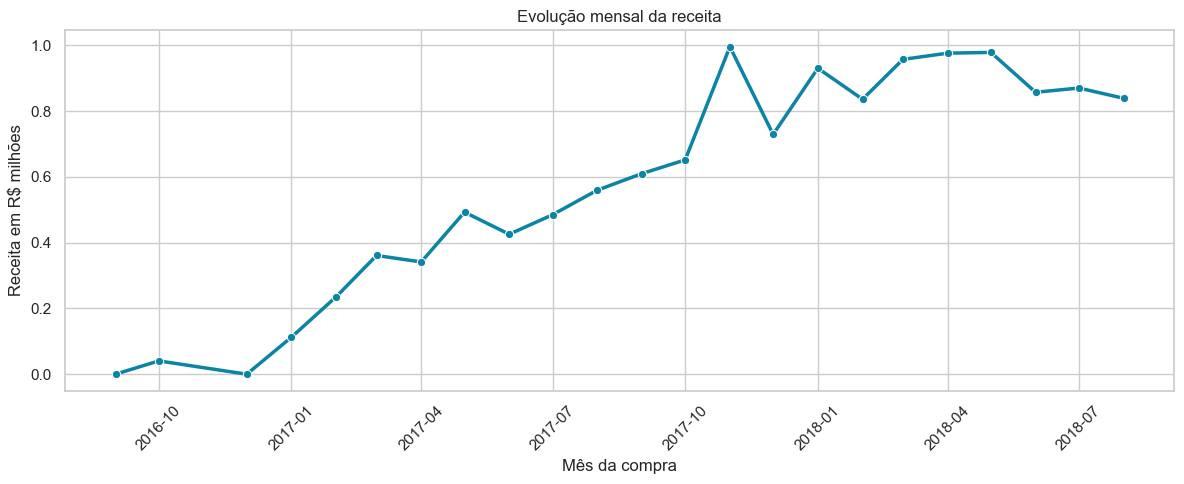

In [32]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_plot_df,
    x="purchase_month",
    y="receita_milhoes",
    marker="o",
    linewidth=2.5,
    color="#0b84a5"
)

plt.title("Evolução mensal da receita")
plt.xlabel("Mês da compra")
plt.ylabel("Receita em R$ milhões")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Evolução mensal da receita.

Leitura para estudo
Esse gráfico mostra como a receita variou mês a mês.

É uma das formas mais diretas de visualizar crescimento em negócios com série temporal.

Leitura para o relatório
Esse é um dos gráficos mais importantes do trabalho.

A leitura esperada é que a receita mensal cresça fortemente ao longo da série, com clara aceleração a partir de 2017 e manutenção em patamar elevado em 2018.

Uma forma de escrever isso no relatório é:

A evolução mensal da receita evidencia uma trajetória de forte expansão da operação, indicando ganho consistente de escala ao longo do período analisado.

## 31. Gráfico de evolução mensal de pedidos

Agora vamos analisar o crescimento do volume de pedidos ao longo do tempo.

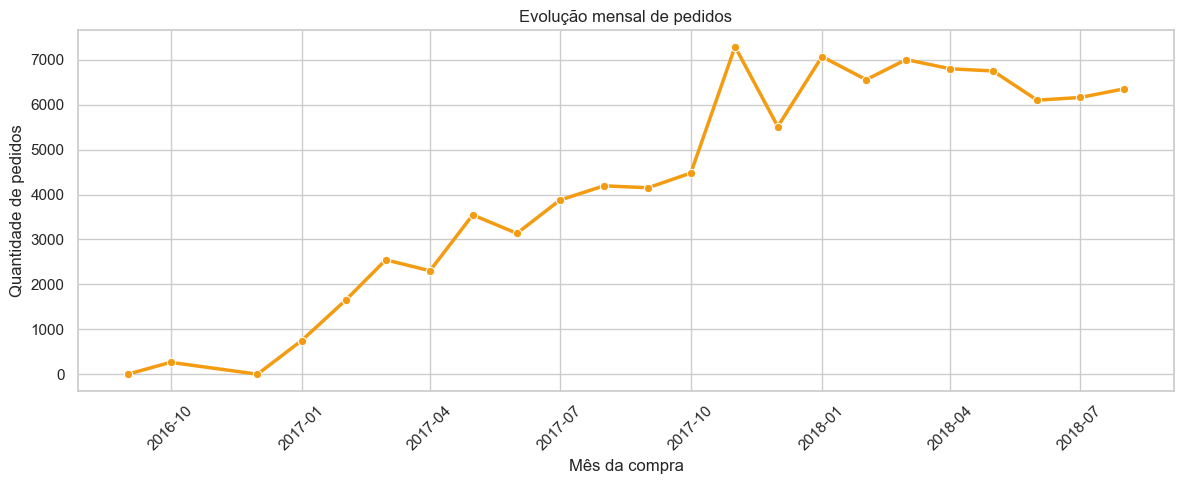

In [33]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_plot_df,
    x="purchase_month",
    y="pedidos",
    marker="o",
    linewidth=2.5,
    color="#f39c12"
)

plt.title("Evolução mensal de pedidos")
plt.xlabel("Mês da compra")
plt.ylabel("Quantidade de pedidos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 que esta etapa gera
Gera o gráfico Evolução mensal de pedidos.

Leitura para estudo
Enquanto o gráfico anterior mostrava crescimento financeiro, este mostra crescimento de volume.

Comparar os dois ajuda a entender se a expansão do negócio foi puxada principalmente por mais pedidos, por ticket maior ou pelos dois.

Leitura para o relatório
Se pedidos e receita crescem juntos, isso fortalece a tese de expansão orgânica da operação.

Você pode escrever algo como:

O crescimento da receita foi acompanhado pela ampliação do volume de pedidos, o que indica ganho real de tração comercial e não apenas variação de preço ou mix.

## 32. Gráfico de evolução do ticket médio

Agora vamos observar se o valor médio por pedido mudou ao longo do tempo.

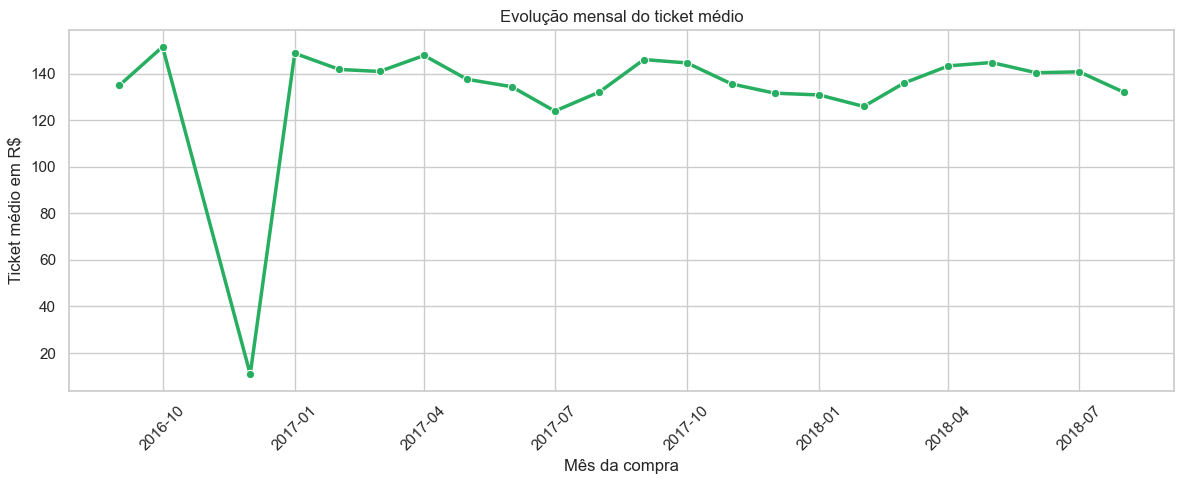

In [34]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_plot_df,
    x="purchase_month",
    y="ticket_medio",
    marker="o",
    linewidth=2.5,
    color="#27ae60"
)

plt.title("Evolução mensal do ticket médio")
plt.xlabel("Mês da compra")
plt.ylabel("Ticket médio em R$")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Evolução mensal do ticket médio.

Leitura para estudo
Esse gráfico mostra se o pedido médio ficou mais caro, mais barato ou relativamente estável ao longo do tempo.

Leitura para o relatório
Esse resultado ajuda muito na interpretação do crescimento.

Se o ticket médio estiver relativamente estável, isso sugere que o crescimento foi puxado principalmente pelo aumento do número de pedidos.
Se ele crescer junto, indica que houve expansão de volume com maior monetização por pedido.

Uma leitura possível é:

O comportamento do ticket médio mostra que o crescimento da operação não dependeu exclusivamente de inflação de valor por pedido, mas foi sustentado principalmente pela ampliação da base transacional.

## 33. Comparando receita, pedidos e ticket médio na mesma tabela

Depois dos gráficos, vale a pena olhar a tabela consolidada com mais atenção.

In [35]:
monthly_kpi_df

,purchase_month,pedidos,receita,ticket_medio
0,2016-09-01,1,134.97,134.970000
1,2016-10-01,265,40451.80,151.504869
2,2016-12-01,1,10.90,10.900000
3,2017-01-01,750,112573.39,148.709894
4,2017-02-01,1653,235483.40,141.772065
5,2017-03-01,2546,360865.25,140.907946
6,2017-04-01,2303,341209.62,147.773764
7,2017-05-01,3546,492620.44,137.526644
8,2017-06-01,3135,425387.66,134.361232
9,2017-07-01,3872,484637.74,123.884903


 que esta etapa gera
Mostra a tabela mensal completa com:

pedidos
receita
ticket médio
Leitura para estudo
O gráfico ajuda a enxergar tendência.
A tabela ajuda a conferir números de forma detalhada.

Leitura para o relatório
Aqui você pode extrair períodos específicos de aceleração, estabilidade ou queda, caso queira enriquecer o texto executivo com mais precisão.

## 34. Identificando o mês de maior receita

Agora vamos descobrir qual foi o mês com maior receita dentro da série analisada.

In [36]:
mes_maior_receita = monthly_kpi_df.loc[monthly_kpi_df["receita"].idxmax()]
mes_maior_receita

purchase_month    2017-11-01 00:00:00
pedidos                          7289
receita                     995199.94
ticket_medio               135.567353
Name: 13, dtype: object

O que esta etapa gera
Mostra a linha da tabela referente ao mês com maior receita.

Leitura para estudo
Esse tipo de consulta é muito útil para identificar picos de performance.

Leitura para o relatório
Esse achado pode enriquecer o texto da análise temporal, por exemplo destacando o auge da série ou a maturação da operação.

## 35. Identificando o mês de maior volume de pedidos

Vamos agora descobrir qual mês concentrou o maior número de pedidos.

In [37]:
mes_maior_pedidos = monthly_kpi_df.loc[monthly_kpi_df["pedidos"].idxmax()]
mes_maior_pedidos

purchase_month    2017-11-01 00:00:00
pedidos                          7289
receita                     995199.94
ticket_medio               135.567353
Name: 13, dtype: object

O que esta etapa gera
Mostra o mês com maior volume de pedidos.

Leitura para estudo
Isso ajuda a perceber se o pico de receita coincide com o pico de volume.

Leitura para o relatório
Se o mês de maior receita e o de maior volume forem próximos ou iguais, isso reforça que o desempenho comercial foi puxado por escala operacional.

## 36. Crescimento percentual entre o início e o final da série

Agora vamos fazer uma leitura simples da expansão da operação comparando o início e o final do período.

In [38]:
primeiro_mes = monthly_kpi_df.iloc[0]
ultimo_mes = monthly_kpi_df.iloc[-1]

crescimento_receita = (ultimo_mes["receita"] - primeiro_mes["receita"]) / primeiro_mes["receita"]
crescimento_pedidos = (ultimo_mes["pedidos"] - primeiro_mes["pedidos"]) / primeiro_mes["pedidos"]

print("Receita no primeiro mês:", round(primeiro_mes["receita"], 2))
print("Receita no último mês:", round(ultimo_mes["receita"], 2))
print("Crescimento percentual da receita:", round(crescimento_receita * 100, 2), "%")

print("Pedidos no primeiro mês:", int(primeiro_mes["pedidos"]))
print("Pedidos no último mês:", int(ultimo_mes["pedidos"]))
print("Crescimento percentual de pedidos:", round(crescimento_pedidos * 100, 2), "%")

Receita no primeiro mês: 134.97
Receita no último mês: 838650.76
Crescimento percentual da receita: 621260.87 %
Pedidos no primeiro mês: 1
Pedidos no último mês: 6351
Crescimento percentual de pedidos: 635000.0 %


O que esta etapa gera
Calcula o crescimento percentual entre o primeiro e o último mês da série.

Leitura para estudo
Essa é uma forma simples e intuitiva de medir evolução temporal.

Leitura para o relatório
Esse resultado fortalece o argumento de crescimento, mas precisa ser interpretado com cuidado, porque o primeiro mês pode ter base muito pequena.

Ou seja, ele é útil como sinal de expansão, mas não deve ser usado isoladamente como argumento principal.

## 37. Considerações executivas da fase 4

A análise temporal mostra que a operação da Olist ganhou escala ao longo do período analisado.

Receita e pedidos crescem de forma consistente, o que sustenta a tese de expansão comercial do negócio.

Ao observar o ticket médio em conjunto, é possível entender melhor a natureza desse crescimento: se ele veio principalmente por aumento de volume, por maior monetização por pedido ou por ambos.

Do ponto de vista executivo, esta etapa reforça que a Olist não apenas operava em múltiplas categorias e regiões, mas também apresentava sinais claros de tração e amadurecimento comercial.

Fechamento da Parte 4
Ao final desta fase, você terá construído:

a tabela mensal de KPIs
o gráfico de evolução da receita
o gráfico de evolução de pedidos
o gráfico de ticket médio
a identificação dos picos de receita e volume
uma primeira leitura temporal do crescimento
Essa parte é central para sustentar o argumento de que o negócio estava em expansão.

O que vem na Parte 5
O próximo passo natural é entrar em:

Parte 5 — Categorias, portfólio e concentração de receita
Nessa fase, vamos analisar:

quais categorias mais geram receita
se a receita está concentrada em poucas categorias
o que isso significa estrategicamente para o negócio

Parte 5 — Categorias, portfólio e concentração de receita


## 38. Início da análise por categorias

Depois de analisar a evolução temporal do negócio, o próximo passo é entender como a receita está distribuída entre as categorias de produtos.

Essa etapa é importante porque mostra quais segmentos sustentam o faturamento da operação e onde existe maior concentração de valor.

Do ponto de vista executivo, a análise por categoria ajuda a responder:
- quais verticais são mais relevantes para o negócio
- se o crescimento depende de poucas categorias
- onde existem oportunidades de foco estratégico

In [39]:
category_perf_df = (
    items_en_df.groupby("product_category_name_english", dropna=False, as_index=False)
    .agg(
        receita=("price", "sum"),
        quantidade_itens=("order_item_id", "count"),
        pedidos=("order_id", "nunique")
    )
    .sort_values("receita", ascending=False)
)

category_perf_df.head(10)

,product_category_name_english,receita,quantidade_itens,pedidos
43,health_beauty,1258681.34,9670,8836
70,watches_gifts,1205005.68,5991,5624
7,bed_bath_table,1036988.68,11115,9417
65,sports_leisure,988048.97,8641,7720
15,computers_accessories,911954.32,7827,6689
39,furniture_decor,729762.49,8334,6449
20,cool_stuff,635290.85,3796,3632
49,housewares,632248.66,6964,5884
5,auto,592720.11,4235,3897
42,garden_tools,485256.46,4347,3518


O que esta etapa gera
Esse bloco cria a tabela category_perf_df, com uma visão consolidada por categoria de produto.

Ela traz três medidas importantes:

receita
quanto cada categoria faturou

quantidade_itens
quantos itens foram vendidos naquela categoria

pedidos
em quantos pedidos aquela categoria apareceu

Leitura para estudo
Aqui você está fazendo uma agregação por categoria em vez de por pedido ou por mês.

Isso é muito útil para responder perguntas de portfólio, como:

quais produtos mais contribuem para o negócio
quais categorias vendem mais
quais categorias combinam volume e monetização
Leitura para o relatório
Essa tabela é a base da análise de portfólio.

Ela ajuda a mostrar que o crescimento da Olist não acontece de forma totalmente homogênea. Algumas categorias puxam mais receita do que outras, o que abre espaço para decisões estratégicas de:

foco comercial
marketing
sortimento
logística prioritária

## 39. Observando as categorias líderes

Agora vamos observar as categorias que aparecem no topo do ranking de receita.

In [40]:
top_10_categorias_df = category_perf_df.head(10).copy()
top_10_categorias_df

,product_category_name_english,receita,quantidade_itens,pedidos
43,health_beauty,1258681.34,9670,8836
70,watches_gifts,1205005.68,5991,5624
7,bed_bath_table,1036988.68,11115,9417
65,sports_leisure,988048.97,8641,7720
15,computers_accessories,911954.32,7827,6689
39,furniture_decor,729762.49,8334,6449
20,cool_stuff,635290.85,3796,3632
49,housewares,632248.66,6964,5884
5,auto,592720.11,4235,3897
42,garden_tools,485256.46,4347,3518


O que esta etapa gera
Cria a tabela top_10_categorias_df, contendo as 10 categorias com maior receita.

Se os dados estiverem consistentes com a análise anterior, as categorias líderes devem incluir:

health_beauty
watches_gifts
bed_bath_table
sports_leisure
computers_accessories
Leitura para estudo
Essa etapa é um recorte da tabela geral, focado no topo do ranking.

Leitura para o relatório
Aqui nasce uma mensagem importante:

a geração de receita é puxada por categorias âncora, e não distribuída igualmente entre todo o portfólio.

Essa leitura é muito forte para relatório executivo, porque mostra onde o negócio realmente ganha escala.

## 40. Gráfico Top 10 categorias por receita

Agora vamos transformar esse ranking em um gráfico de barras para facilitar a leitura visual.

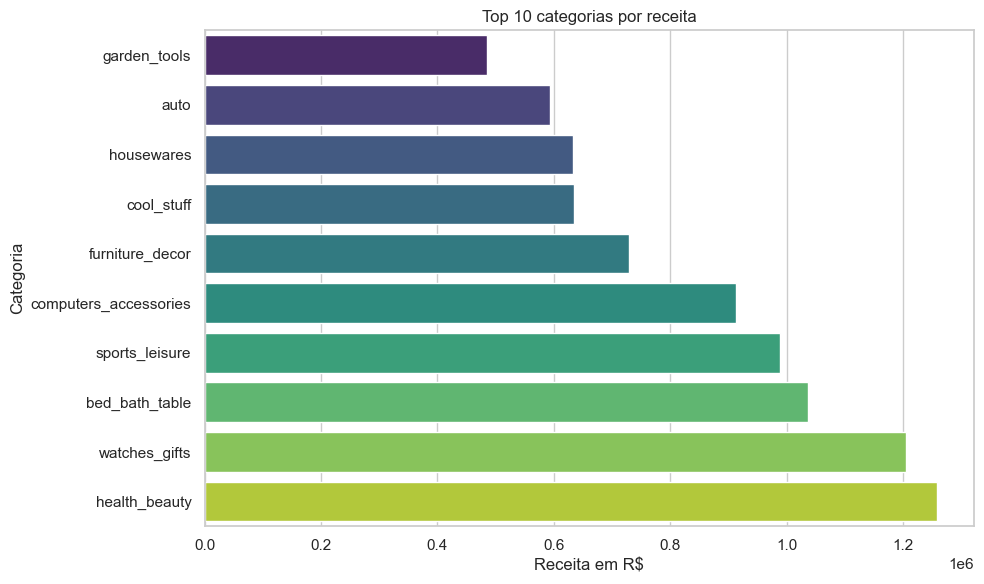

In [41]:
top_10_plot_df = top_10_categorias_df.sort_values("receita", ascending=True).copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_plot_df,
    y="product_category_name_english",
    x="receita",
    hue="product_category_name_english",
    dodge=False,
    palette="viridis",
    legend=False
)

plt.title("Top 10 categorias por receita")
plt.xlabel("Receita em R$")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Top 10 categorias por receita.

Leitura para estudo
Esse tipo de gráfico é excelente para ranking, porque permite comparar categorias com rapidez.

Leitura para o relatório
Esse é um dos gráficos mais importantes da análise comercial.

A leitura executiva pode ser assim:

A receita da operação é fortemente puxada por um conjunto restrito de categorias líderes, com destaque para saúde e beleza, relógios e presentes, cama mesa e banho, esporte e lazer e acessórios de informática.

## 41. Calculando a participação das principais categorias na receita total

Agora vamos medir quanto as 10 principais categorias representam da receita total.

In [42]:
receita_top_10 = top_10_categorias_df["receita"].sum()
receita_total_categorias = category_perf_df["receita"].sum()
participacao_top_10 = receita_top_10 / receita_total_categorias

print("Receita das 10 principais categorias:", round(receita_top_10, 2))
print("Receita total das categorias:", round(receita_total_categorias, 2))
print("Participação das 10 principais categorias:", round(participacao_top_10 * 100, 2), "%")

Receita das 10 principais categorias: 8475957.56
Receita total das categorias: 13591643.7
Participação das 10 principais categorias: 62.36 %


O que esta etapa gera
Calcula quanto da receita total está concentrada nas 10 categorias líderes.

Leitura para estudo
Esse cálculo é importante porque não basta saber quem lidera. Também é útil medir o tamanho da concentração.

Leitura para o relatório
Se essa participação for alta, isso reforça a leitura de que o negócio depende mais fortemente de algumas verticais específicas.

Executivamente, isso pode ser interpretado de duas formas:

como força, porque existem categorias consolidadas
como risco, caso haja dependência excessiva de poucas frentes

## 42. Calculando o ticket médio por categoria

Agora vamos identificar o valor médio por pedido em cada categoria.

Essa análise ajuda a diferenciar categorias que crescem por volume das categorias que crescem por maior valor por pedido.

In [43]:
category_perf_df["ticket_medio_categoria"] = (
    category_perf_df["receita"] / category_perf_df["pedidos"]
)

category_perf_df.sort_values("ticket_medio_categoria", ascending=False).head(10)

,product_category_name_english,receita,quantidade_itens,pedidos,ticket_medio_categoria
14,computers,222963.13,203,181,1231.840497
64,small_appliances_home_oven_and_coffee,47445.71,76,75,632.609467
45,home_appliances_2,113317.74,238,234,484.263846
0,agro_industry_and_commerce,72530.47,212,182,398.519066
56,musical_instruments,191498.88,680,628,304.934522
63,small_appliances,190648.58,679,630,302.616794
34,fixed_telephony,59583.00,264,217,274.576037
19,construction_tools_safety,40544.52,194,167,242.781557
1,air_conditioning,55024.96,297,253,217.489960
57,office_furniture,273960.70,1691,1273,215.208720


O que esta etapa gera
Cria a coluna ticket_medio_categoria e mostra as categorias com maior valor médio por pedido.

Leitura para estudo
Essa análise é útil porque receita total sozinha não conta toda a história.

Uma categoria pode ter alta receita por:

vender muito
vender itens mais caros
combinar os dois fatores
Leitura para o relatório
Essa leitura pode enriquecer muito o texto executivo.

Por exemplo:

Algumas categorias se destacam não apenas por volume, mas também por maior monetização por pedido, o que pode indicar potencial de margem, valor percebido ou posicionamento premium.

## 43. Comparando receita e quantidade de pedidos das categorias líderes

Agora vamos olhar as categorias líderes em uma ótica combinada de receita e número de pedidos.

In [44]:
top_10_categorias_df[["product_category_name_english", "receita", "pedidos", "quantidade_itens"]]

,product_category_name_english,receita,pedidos,quantidade_itens
43,health_beauty,1258681.34,8836,9670
70,watches_gifts,1205005.68,5624,5991
7,bed_bath_table,1036988.68,9417,11115
65,sports_leisure,988048.97,7720,8641
15,computers_accessories,911954.32,6689,7827
39,furniture_decor,729762.49,6449,8334
20,cool_stuff,635290.85,3632,3796
49,housewares,632248.66,5884,6964
5,auto,592720.11,3897,4235
42,garden_tools,485256.46,3518,4347


O que esta etapa gera
Mostra, para as categorias líderes:

receita
quantidade de pedidos
quantidade de itens
Leitura para estudo
Esse comparativo ajuda a perceber se a categoria cresce por frequência de compra ou por valor acumulado.

Leitura para o relatório
Essa leitura ajuda a diferenciar categorias:

de massa, com muito volume
de maior valor, com menos pedidos e maior receita média
híbridas, que combinam alto volume e alta monetização

## 44. Criando uma coluna de participação percentual da receita por categoria

Vamos agora calcular a participação de cada categoria na receita total.

In [45]:
category_perf_df["participacao_receita"] = (
    category_perf_df["receita"] / category_perf_df["receita"].sum()
)

category_perf_df.head(10)

,product_category_name_english,receita,quantidade_itens,pedidos,ticket_medio_categoria,participacao_receita
43,health_beauty,1258681.34,9670,8836,142.449224,0.092607
70,watches_gifts,1205005.68,5991,5624,214.261323,0.088658
7,bed_bath_table,1036988.68,11115,9417,110.118794,0.076296
65,sports_leisure,988048.97,8641,7720,127.985618,0.072695
15,computers_accessories,911954.32,7827,6689,136.336421,0.067097
39,furniture_decor,729762.49,8334,6449,113.159015,0.053692
20,cool_stuff,635290.85,3796,3632,174.914882,0.046741
49,housewares,632248.66,6964,5884,107.452186,0.046517
5,auto,592720.11,4235,3897,152.096513,0.043609
42,garden_tools,485256.46,4347,3518,137.935321,0.035703


O que esta etapa gera
Cria a coluna participacao_receita, mostrando quanto cada categoria representa no faturamento total.

Leitura para estudo
Essa métrica é muito útil quando você quer transformar valores absolutos em participação relativa.

Leitura para o relatório
Com essa coluna, você pode construir frases mais executivas, como:

As principais categorias concentram parcela relevante da receita, indicando que a captura de valor do marketplace é puxada por verticais específicas.

## 45. Observando a concentração das cinco principais categorias

Além do top 10, vamos medir a concentração das 5 maiores categorias.

In [46]:
top_5_categorias_df = category_perf_df.head(5).copy()
participacao_top_5 = top_5_categorias_df["receita"].sum() / category_perf_df["receita"].sum()

print("Participação das 5 principais categorias:", round(participacao_top_5 * 100, 2), "%")
top_5_categorias_df

Participação das 5 principais categorias: 39.74 %


,product_category_name_english,receita,quantidade_itens,pedidos,ticket_medio_categoria,participacao_receita
43,health_beauty,1258681.34,9670,8836,142.449224,0.092607
70,watches_gifts,1205005.68,5991,5624,214.261323,0.088658
7,bed_bath_table,1036988.68,11115,9417,110.118794,0.076296
65,sports_leisure,988048.97,8641,7720,127.985618,0.072695
15,computers_accessories,911954.32,7827,6689,136.336421,0.067097


O que esta etapa gera
Calcula quanto da receita total está concentrada nas 5 principais categorias.

Leitura para estudo
Esse é um indicador simples de concentração, muito útil em análise de portfólio.

Leitura para o relatório
Se a participação for relevante, isso reforça a ideia de foco estratégico.

Você pode interpretar assim:

O faturamento da operação é fortemente sustentado por um núcleo reduzido de categorias, o que sugere oportunidades de aprofundamento comercial nessas frentes, mas também exige atenção à concentração do portfólio.

## 46. Considerações executivas da fase 5

A análise por categoria mostra que o crescimento da Olist é sustentado por um conjunto específico de verticais com forte capacidade de geração de receita.

Essa leitura é importante porque demonstra que o portfólio não contribui de forma uniforme para o desempenho do negócio.

Do ponto de vista executivo, isso abre duas reflexões centrais.

A primeira é positiva: existem categorias claramente fortes, que podem receber maior foco em marketing, sortimento, pricing e estratégia comercial.

A segunda é de risco: quando a geração de valor está concentrada, a empresa precisa monitorar cuidadosamente sua dependência de determinadas categorias.

Fechamento da Parte 5
Ao final desta fase, você terá:

a tabela de desempenho por categoria
o ranking das categorias líderes
o gráfico Top 10 categorias por receita
a participação das 10 principais categorias
a participação das 5 principais categorias
uma leitura de concentração do portfólio
Essa parte fortalece bastante a seção comercial do relatório executivo.

O que vem na Parte 6
O próximo passo natural é entrar em:

Parte 6 — Geografia, estados e concentração regional
Nessa fase, vamos analisar:

quais estados geram mais receita
onde estão os maiores volumes de pedidos
como prazo e satisfação variam entre estados
por que São Paulo aparece como principal polo da operação

Parte 6 — Geografia, estados e concentração regional


## 47. Início da análise geográfica

Depois de entender a evolução temporal do negócio e a concentração por categorias, o próximo passo é analisar a dimensão geográfica da operação.

Nesta etapa, vamos observar os estados com maior relevância em receita e volume, além de comparar indicadores de prazo médio de entrega e nota média de avaliação.

Essa análise é importante porque ajuda a responder:
- onde o negócio gera mais valor
- onde a operação é mais eficiente
- onde a satisfação do cliente é mais alta ou mais baixa
- se existem diferenças regionais relevantes que merecem atenção estratégica

In [47]:
state_perf_df = (
    delivered_df.groupby("customer_state", as_index=False)
    .agg(
        receita=("receita", "sum"),
        pedidos=("order_id", "nunique"),
        prazo_medio=("prazo_entrega_dias", "mean"),
        nota_media=("review_score", "mean")
    )
    .sort_values("receita", ascending=False)
)

state_perf_df.head(10)

,customer_state,receita,pedidos,prazo_medio,nota_media
25,SP,5093379.50,40501,8.764857,4.246196
18,RJ,1766256.97,12350,15.318877,3.963439
10,MG,1558668.28,11354,12.011948,4.192707
22,RS,732420.80,5345,15.319540,4.185496
17,PR,668891.26,4923,12.000591,4.238260
23,SC,508578.90,3546,14.975162,4.131050
4,BA,495416.93,3256,19.356057,3.929452
6,DF,298492.74,2080,12.996125,4.131642
8,GO,285780.24,1957,15.604079,4.102904
7,ES,269230.52,1995,15.798111,4.082406


O que esta etapa gera
Esse bloco cria a tabela state_perf_df, consolidando o desempenho da operação por estado.

Ela reúne quatro métricas importantes:

receita
quanto cada estado gerou de faturamento

pedidos
quantos pedidos entregues foram realizados naquele estado

prazo_medio
tempo médio de entrega em dias

nota_media
avaliação média dos clientes daquele estado

Leitura para estudo
Aqui você está mudando a unidade de análise.
Antes, você analisava por mês ou por categoria. Agora, está analisando por estado do cliente.

Isso é muito importante porque várias perguntas de negócio só aparecem quando olhamos a geografia.

Leitura para o relatório
Essa tabela é a base da leitura regional do relatório.

Ela permitirá mostrar que o desempenho da Olist não é uniforme em todo o país e que alguns mercados concentram mais valor do que outros.

## 48. Observando os estados com maior receita

Agora vamos olhar o topo do ranking regional para identificar os estados mais relevantes economicamente.

In [48]:
top_estados_receita_df = state_perf_df.head(10).copy()
top_estados_receita_df

,customer_state,receita,pedidos,prazo_medio,nota_media
25,SP,5093379.50,40501,8.764857,4.246196
18,RJ,1766256.97,12350,15.318877,3.963439
10,MG,1558668.28,11354,12.011948,4.192707
22,RS,732420.80,5345,15.319540,4.185496
17,PR,668891.26,4923,12.000591,4.238260
23,SC,508578.90,3546,14.975162,4.131050
4,BA,495416.93,3256,19.356057,3.929452
6,DF,298492.74,2080,12.996125,4.131642
8,GO,285780.24,1957,15.604079,4.102904
7,ES,269230.52,1995,15.798111,4.082406


O que esta etapa gera
Cria a tabela top_estados_receita_df, com os 10 estados que mais geraram receita.

Leitura para estudo
Esse recorte permite focar nos mercados mais importantes, em vez de olhar todos os estados ao mesmo tempo.

Leitura para o relatório
Aqui você provavelmente verá São Paulo na liderança isolada, seguido por estados como:

Rio de Janeiro
Minas Gerais
Rio Grande do Sul
Paraná
Esse resultado é muito importante para o texto executivo, porque mostra que existe uma concentração regional clara de valor.

## 49. Gráfico de receita por estado

Vamos agora transformar o ranking de receita dos estados em um gráfico de barras.

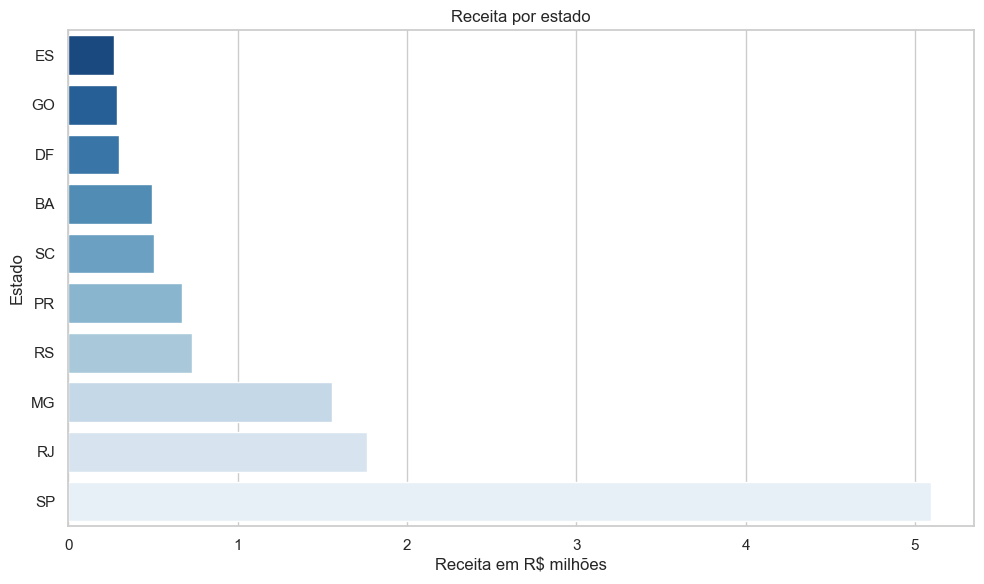

In [49]:
top_estados_plot_df = top_estados_receita_df.sort_values("receita", ascending=True).copy()
top_estados_plot_df["receita_milhoes"] = top_estados_plot_df["receita"] / 1000000

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_estados_plot_df,
    y="customer_state",
    x="receita_milhoes",
    hue="customer_state",
    dodge=False,
    palette="Blues_r",
    legend=False
)

plt.title("Receita por estado")
plt.xlabel("Receita em R$ milhões")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Receita por estado.

Leitura para estudo
Esse tipo de gráfico é ideal para comparar ranking regional.

Leitura para o relatório
Esse gráfico sustenta uma mensagem executiva muito importante:

A geração de receita da operação é fortemente concentrada em poucos estados, com destaque muito expressivo para São Paulo, que funciona como o principal núcleo econômico da base analisada.

## 50. Calculando a participação de São Paulo na receita total

Como São Paulo tende a aparecer como líder com bastante destaque, vale medir quanto ele representa da receita total.

In [50]:
receita_total_estados = state_perf_df["receita"].sum()
receita_sp = state_perf_df.loc[state_perf_df["customer_state"] == "SP", "receita"].values[0]
participacao_sp = receita_sp / receita_total_estados

print("Receita total dos estados:", round(receita_total_estados, 2))
print("Receita de São Paulo:", round(receita_sp, 2))
print("Participação de São Paulo na receita total:", round(participacao_sp * 100, 2), "%")

Receita total dos estados: 13279836.59
Receita de São Paulo: 5093379.5
Participação de São Paulo na receita total: 38.35 %


O que esta etapa gera
Esse bloco calcula a participação do estado de São Paulo na receita total da operação analisada.

Leitura para estudo
Essa é uma boa prática analítica: quando um elemento se destaca muito no ranking, vale medir objetivamente o tamanho dessa liderança.

Leitura para o relatório
Esse número ajuda muito a reforçar a narrativa de concentração geográfica.

Você pode interpretar assim:

São Paulo concentra parcela muito relevante da receita total, indicando que a operação depende fortemente do desempenho do principal mercado consumidor do país.

## 51. Ranking de estados por volume de pedidos

Além da receita, também é importante observar quais estados concentram o maior volume de pedidos.

In [51]:
state_perf_df.sort_values("pedidos", ascending=False).head(10)

,customer_state,receita,pedidos,prazo_medio,nota_media
25,SP,5093379.50,40501,8.764857,4.246196
18,RJ,1766256.97,12350,15.318877,3.963439
10,MG,1558668.28,11354,12.011948,4.192707
22,RS,732420.80,5345,15.319540,4.185496
17,PR,668891.26,4923,12.000591,4.238260
23,SC,508578.90,3546,14.975162,4.131050
4,BA,495416.93,3256,19.356057,3.929452
6,DF,298492.74,2080,12.996125,4.131642
7,ES,269230.52,1995,15.798111,4.082406
8,GO,285780.24,1957,15.604079,4.102904


O que esta etapa gera
Mostra os estados com maior volume de pedidos entregues.

Leitura para estudo
Essa comparação é importante porque receita alta nem sempre significa maior quantidade de pedidos. Às vezes, o valor médio por pedido é que faz diferença.

Leitura para o relatório
Se São Paulo liderar tanto em receita quanto em pedidos, isso reforça o papel do estado como principal motor da operação.

## 52. Gráfico de prazo médio de entrega por estado

Agora vamos observar o desempenho logístico regional, analisando o prazo médio de entrega nos principais estados.

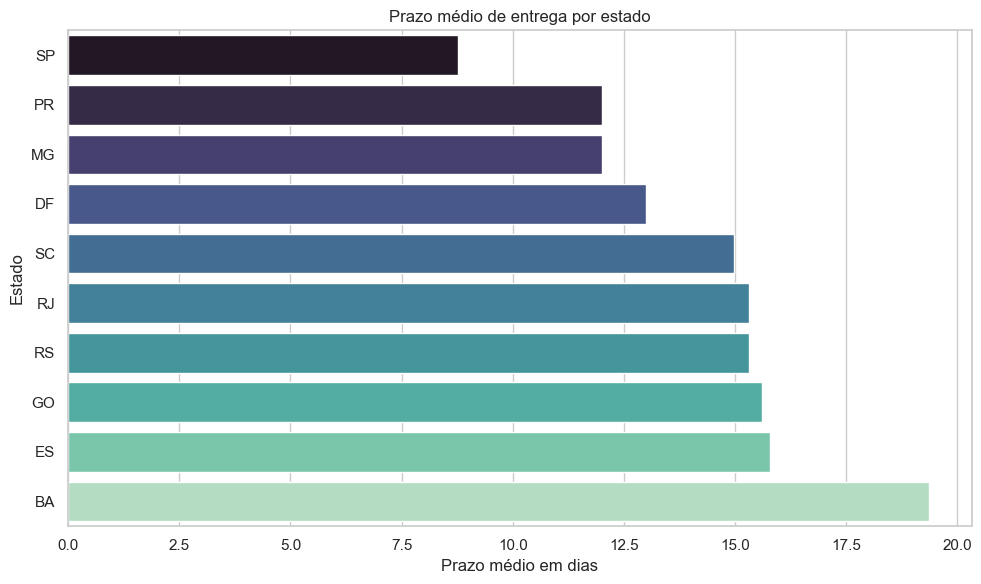

In [52]:
top_estados_prazo_df = top_estados_receita_df.sort_values("prazo_medio", ascending=True).copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_estados_prazo_df,
    y="customer_state",
    x="prazo_medio",
    hue="customer_state",
    dodge=False,
    palette="mako",
    legend=False
)

plt.title("Prazo médio de entrega por estado")
plt.xlabel("Prazo médio em dias")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Prazo médio de entrega por estado.

Leitura para estudo
Esse gráfico mostra que a operação não entrega no mesmo ritmo em todos os estados.

Leitura para o relatório
Essa é uma parte muito valiosa da análise, porque permite mostrar que o crescimento regional vem acompanhado de diferenças logísticas importantes.

Uma leitura possível é:

Embora os principais mercados concentrem grande parte da receita, o prazo médio de entrega varia significativamente entre estados, sugerindo diferenças relevantes de eficiência operacional.



## 53. Gráfico de nota média de avaliação por estado

Além do prazo, queremos entender como a satisfação do cliente se distribui geograficamente.

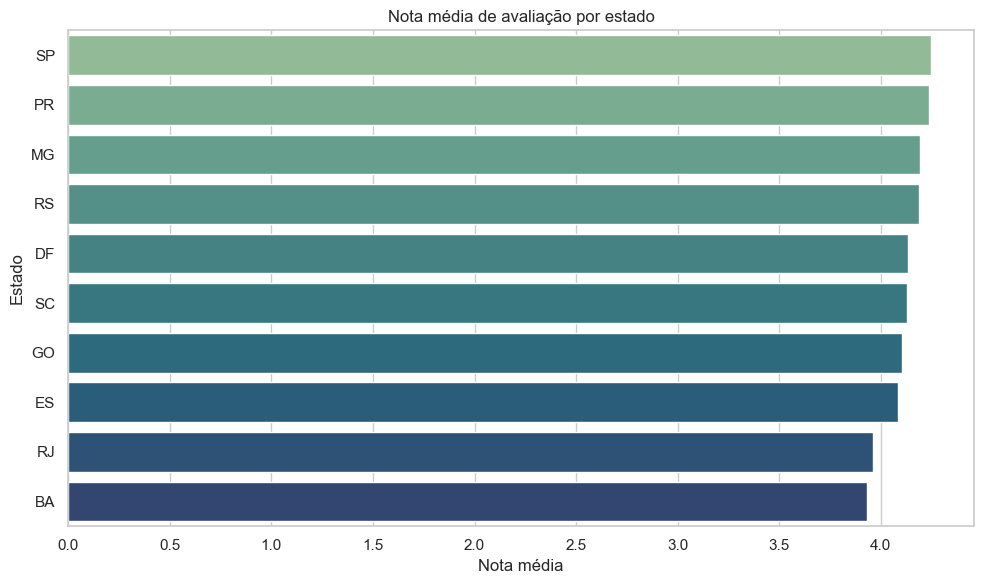

In [53]:
top_estados_nota_df = top_estados_receita_df.sort_values("nota_media", ascending=False).copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_estados_nota_df,
    y="customer_state",
    x="nota_media",
    hue="customer_state",
    dodge=False,
    palette="crest",
    legend=False
)

plt.title("Nota média de avaliação por estado")
plt.xlabel("Nota média")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Nota média de avaliação por estado.

Leitura para estudo
Agora você consegue comparar geografia e percepção do cliente.

Leitura para o relatório
Esse gráfico ajuda a mostrar que experiência do cliente também varia regionalmente.

Isso é importante porque reforça a ideia de que a operação não deve ser tratada como homogênea.

## 54. Cruzando prazo e satisfação em um único gráfico

Agora vamos reunir prazo médio, nota média e peso econômico dos estados em uma só visualização.

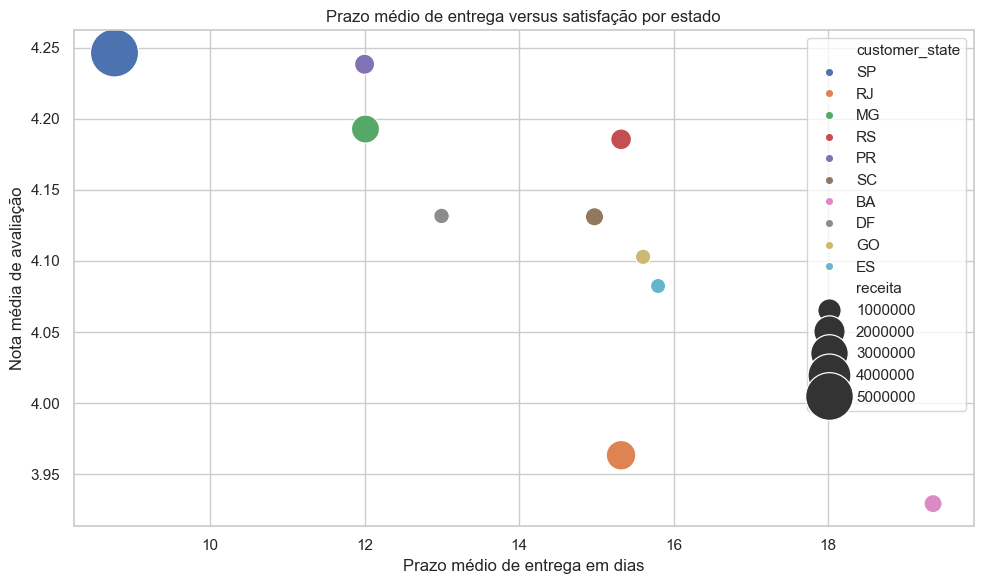

In [54]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=top_estados_receita_df,
    x="prazo_medio",
    y="nota_media",
    size="receita",
    hue="customer_state",
    sizes=(120, 1200)
)

plt.title("Prazo médio de entrega versus satisfação por estado")
plt.xlabel("Prazo médio de entrega em dias")
plt.ylabel("Nota média de avaliação")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Prazo médio de entrega versus satisfação por estado.

Nesse gráfico:

o eixo X mostra o prazo médio
o eixo Y mostra a nota média
o tamanho da bolha representa a receita
a cor identifica o estado
Leitura para estudo
Esse é um ótimo exemplo de visualização multivariada.

Você está conseguindo colocar várias dimensões da análise em um único gráfico.

Leitura para o relatório
Esse é um dos gráficos mais fortes do trabalho, porque mostra de forma muito visual a relação entre logística, satisfação e relevância econômica.

Uma interpretação executiva possível é:

Os estados mais relevantes em receita não apresentam necessariamente o mesmo nível de eficiência logística. Observa-se uma tendência de melhor satisfação nos mercados com prazos menores, sugerindo que a experiência do cliente é sensível à performance operacional regional.

## 55. Identificando os estados mais rápidos e os mais lentos

Agora vamos listar separadamente os estados com melhor e pior prazo médio entre os principais mercados.

In [55]:
print("Estados com menor prazo médio:")
print(top_estados_receita_df.sort_values("prazo_medio", ascending=True).head(5))

print("Estados com maior prazo médio:")
print(top_estados_receita_df.sort_values("prazo_medio", ascending=False).head(5))

Estados com menor prazo médio:
   customer_state     receita  pedidos  prazo_medio  nota_media
25             SP  5093379.50    40501     8.764857    4.246196
17             PR   668891.26     4923    12.000591    4.238260
10             MG  1558668.28    11354    12.011948    4.192707
6              DF   298492.74     2080    12.996125    4.131642
23             SC   508578.90     3546    14.975162    4.131050
Estados com maior prazo médio:
   customer_state     receita  pedidos  prazo_medio  nota_media
4              BA   495416.93     3256    19.356057    3.929452
7              ES   269230.52     1995    15.798111    4.082406
8              GO   285780.24     1957    15.604079    4.102904
22             RS   732420.80     5345    15.319540    4.185496
18             RJ  1766256.97    12350    15.318877    3.963439


O que esta etapa gera
Mostra os estados com melhor e pior desempenho logístico, considerando os principais mercados.

Leitura para estudo
Essa etapa ajuda a transformar o gráfico em uma leitura mais objetiva.

Leitura para o relatório
Aqui você consegue começar a apontar rotas ou mercados onde melhorias operacionais podem gerar mais impacto.

## 56. Identificando os estados com melhor e pior satisfação média

Vamos agora observar os extremos da experiência do cliente entre os estados mais relevantes.

In [56]:
print("Estados com maior nota média:")
print(top_estados_receita_df.sort_values("nota_media", ascending=False).head(5))

print("Estados com menor nota média:")
print(top_estados_receita_df.sort_values("nota_media", ascending=True).head(5))

Estados com maior nota média:
   customer_state     receita  pedidos  prazo_medio  nota_media
25             SP  5093379.50    40501     8.764857    4.246196
17             PR   668891.26     4923    12.000591    4.238260
10             MG  1558668.28    11354    12.011948    4.192707
22             RS   732420.80     5345    15.319540    4.185496
6              DF   298492.74     2080    12.996125    4.131642
Estados com menor nota média:
   customer_state     receita  pedidos  prazo_medio  nota_media
4              BA   495416.93     3256    19.356057    3.929452
18             RJ  1766256.97    12350    15.318877    3.963439
7              ES   269230.52     1995    15.798111    4.082406
8              GO   285780.24     1957    15.604079    4.102904
23             SC   508578.90     3546    14.975162    4.131050


O que esta etapa gera
Mostra os estados com maior e menor nota média de avaliação.

Leitura para estudo
Essa leitura ajuda a identificar diferenças regionais de percepção do cliente.

Leitura para o relatório
Ela é especialmente útil quando comparada aos dados de prazo, porque pode reforçar a hipótese de que logística impacta satisfação.



## 57. Considerações executivas da fase 6

A análise geográfica mostra que a operação da Olist apresenta forte concentração regional de valor, com destaque para São Paulo como principal mercado em receita e volume.

Ao mesmo tempo, os dados indicam que o desempenho logístico e a satisfação do cliente variam entre estados, o que sugere que a expansão territorial do negócio não ocorre com a mesma eficiência em toda a operação.

Do ponto de vista executivo, isso traz uma mensagem importante:
o crescimento geográfico amplia o mercado endereçável, mas também aumenta a complexidade operacional.

Portanto, o desafio estratégico não é apenas vender em mais regiões, mas sustentar qualidade de entrega e experiência do cliente à medida que a operação se expande.

Fechamento da Parte 6
Ao final desta fase, você terá:

a tabela de desempenho por estado
o gráfico de receita por estado
o gráfico de prazo médio por estado
o gráfico de nota média por estado
o gráfico de prazo versus satisfação por estado
a medição da participação de São Paulo na receita total
uma leitura executiva da concentração regional
Essa parte fortalece muito a dimensão de logística e geografia do relatório.

O que vem na Parte 7
O próximo passo natural é entrar em:

Parte 7 — Logística, atraso e impacto na satisfação
Nessa fase, vamos aprofundar:

prazo médio de entrega
atraso versus prazo estimado
distribuição dos atrasos
impacto do atraso na nota
mensagens executivas sobre SLA e experiência do cliente

Parte 7 — Logística, atraso e impacto na satisfação

## 58. Início da análise logística

Depois de entender crescimento, categorias e geografia, vamos aprofundar a dimensão logística da operação.

A logística é uma parte essencial da experiência do cliente no e-commerce, porque conecta a promessa de compra à entrega efetiva do produto.

Nesta etapa, vamos observar:
- prazo médio de entrega
- atraso em relação ao prazo estimado
- proporção de pedidos atrasados
- impacto do atraso na satisfação do cliente

Do ponto de vista executivo, esta é uma das partes mais importantes do estudo, porque mostra como eficiência operacional influencia percepção de valor.

In [57]:
print("Prazo médio de entrega em dias:", round(delivered_df["prazo_entrega_dias"].mean(), 2))
print("Prazo mediano de entrega em dias:", round(delivered_df["prazo_entrega_dias"].median(), 2))
print("Atraso médio em dias:", round(delivered_df["atraso_dias"].mean(), 2))
print("Quantidade de pedidos atrasados:", int(delivered_df["entrega_atrasada"].sum()))
print("Taxa de atraso:", round(delivered_df["entrega_atrasada"].mean() * 100, 2), "%")

Prazo médio de entrega em dias: 12.56
Prazo mediano de entrega em dias: 10.22
Atraso médio em dias: -11.18
Quantidade de pedidos atrasados: 7865
Taxa de atraso: 8.11 %


O que esta etapa gera
Esse bloco resume os principais indicadores logísticos da operação:

prazo médio de entrega
prazo mediano
atraso médio
quantidade de pedidos atrasados
taxa de atraso
Leitura para estudo
Aqui você está começando a olhar a logística com medidas mais completas.

A média mostra o comportamento geral.
A mediana ajuda a reduzir o efeito de casos extremos.
A taxa de atraso traduz o problema em percentual, o que é muito útil para comunicação executiva.

Leitura para o relatório
Esse trecho ajuda a abrir a análise logística com uma leitura clara:

A operação apresenta prazo médio de entrega em torno de 12,56 dias e taxa de atraso próxima de 8,15%, indicando que, embora a maior parte dos pedidos seja concluída dentro da expectativa, ainda existe um volume relevante de fricção operacional.

## 59. Observando a distribuição do prazo de entrega

Além da média, é importante entender como os prazos se distribuem.

Vamos visualizar isso com um histograma.

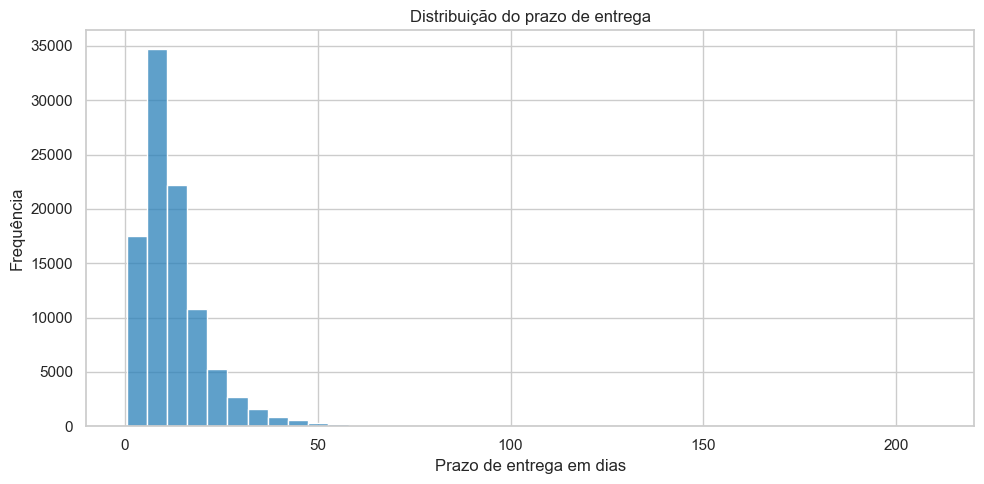

In [58]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivered_df,
    x="prazo_entrega_dias",
    bins=40,
    color="#2980b9"
)

plt.title("Distribuição do prazo de entrega")
plt.xlabel("Prazo de entrega em dias")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Distribuição do prazo de entrega.

Leitura para estudo
Esse histograma mostra se os prazos estão concentrados em uma faixa específica ou se existe muita dispersão.

Leitura para o relatório
Esse gráfico ajuda a mostrar que a média sozinha não conta toda a história.

Se houver cauda longa, a leitura executiva pode ser:

Embora a maior parte das entregas ocorra dentro de uma faixa mais concentrada de prazo, há uma cauda de pedidos com entregas significativamente mais longas, o que pode comprometer a experiência do cliente em casos específicos.

## 60. Observando a distribuição do atraso em relação ao prazo estimado

Agora vamos olhar especificamente o comportamento do atraso, isto é, o quanto a entrega ficou antes ou depois da data estimada.

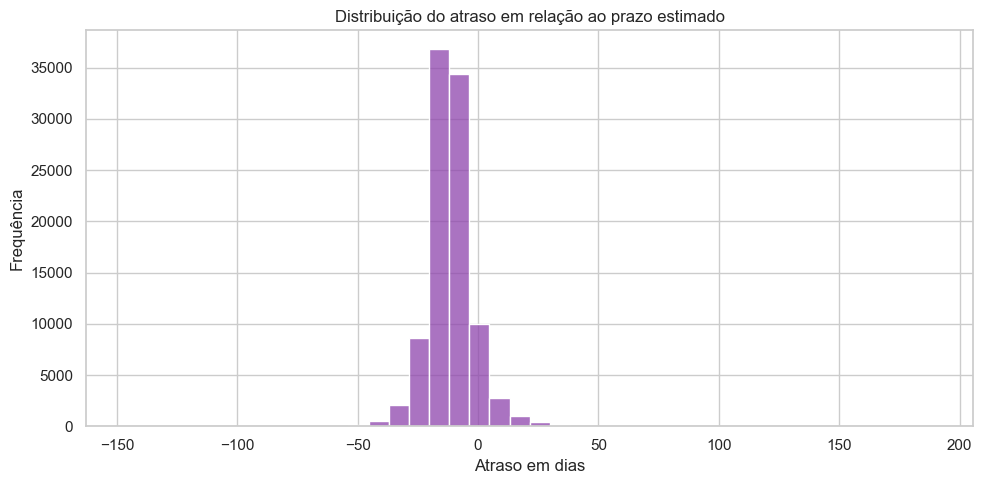

In [59]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=delivered_df,
    x="atraso_dias",
    bins=40,
    color="#8e44ad"
)

plt.title("Distribuição do atraso em relação ao prazo estimado")
plt.xlabel("Atraso em dias")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Distribuição do atraso em relação ao prazo estimado.

Leitura para estudo
Nessa variável:

valores negativos indicam entrega antes do prazo estimado
valores positivos indicam atraso
Leitura para o relatório
Esse gráfico é muito bom para mostrar que nem toda entrega fora da média é necessariamente ruim.

Uma leitura forte é:

Boa parte das entregas ocorre antes do prazo estimado, mas existe uma faixa de pedidos com atraso positivo que representa risco direto para a satisfação do cliente.

## 61. Separando pedidos no prazo e pedidos atrasados

Agora vamos construir uma visão resumida comparando os dois grupos.

In [60]:
logistica_resumo_df = delivered_df.groupby("entrega_atrasada", as_index=False).agg(
    quantidade_pedidos=("order_id", "nunique"),
    prazo_medio=("prazo_entrega_dias", "mean"),
    atraso_medio=("atraso_dias", "mean"),
    nota_media=("review_score", "mean"),
    receita_total=("receita", "sum")
)

logistica_resumo_df["situacao_entrega"] = logistica_resumo_df["entrega_atrasada"].map({
    False: "No prazo",
    True: "Atrasado"
})

logistica_resumo_df

,entrega_atrasada,quantidade_pedidos,prazo_medio,atraso_medio,nota_media,receita_total,situacao_entrega
0,False,88652,10.890518,-13.01161,4.293737,12116137.38,No prazo
1,True,7826,31.530239,9.55170,2.566494,1163699.21,Atrasado


O que esta etapa gera
Cria a tabela logistica_resumo_df, comparando pedidos:

no prazo
atrasados
com base em:

quantidade
prazo médio
atraso médio
nota média
receita total
Leitura para estudo
Esse é um ótimo exemplo de tabela gerencial.
Ela resume, em uma única visão, o comportamento dos dois grupos mais importantes da análise logística.

Leitura para o relatório
Essa tabela é extremamente valiosa porque mostra que o atraso não é só um problema de SLA, mas também um problema de experiência.

## 62. Gráfico do impacto do atraso na satisfação do cliente

Agora vamos visualizar um dos achados mais relevantes da análise.

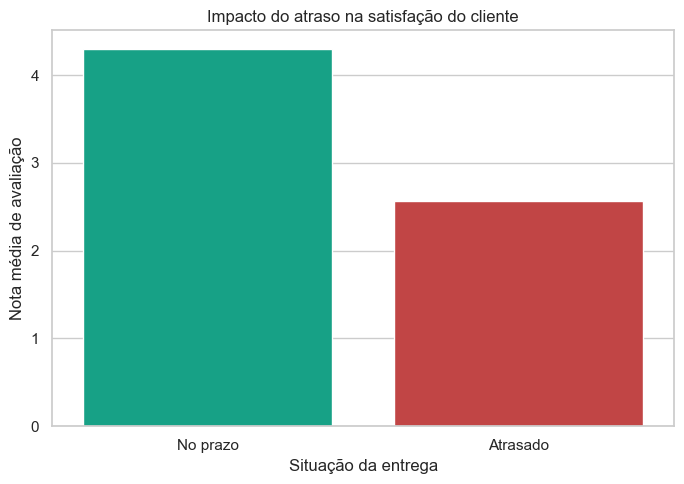

In [61]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=logistica_resumo_df,
    x="situacao_entrega",
    y="nota_media",
    hue="situacao_entrega",
    dodge=False,
    palette=["#00b894", "#d63031"],
    legend=False
)

plt.title("Impacto do atraso na satisfação do cliente")
plt.xlabel("Situação da entrega")
plt.ylabel("Nota média de avaliação")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Impacto do atraso na satisfação do cliente.

Leitura para estudo
Esse gráfico é simples, mas muito poderoso.
Ele compara diretamente a nota média dos pedidos no prazo com a nota média dos pedidos atrasados.

Leitura para o relatório
Esse provavelmente é o gráfico mais forte do trabalho.

A leitura executiva é direta:

Pedidos entregues no prazo mantêm satisfação elevada, enquanto pedidos atrasados apresentam queda acentuada de avaliação. Isso demonstra que a logística é um dos principais determinantes da experiência do cliente no marketplace.

## 63. Medindo a queda de satisfação causada pelo atraso

Vamos quantificar o efeito do atraso na nota média.

In [62]:
nota_no_prazo = logistica_resumo_df.loc[
    logistica_resumo_df["situacao_entrega"] == "No prazo",
    "nota_media"
].values[0]

nota_atrasado = logistica_resumo_df.loc[
    logistica_resumo_df["situacao_entrega"] == "Atrasado",
    "nota_media"
].values[0]

queda_absoluta = nota_no_prazo - nota_atrasado
queda_percentual = queda_absoluta / nota_no_prazo

print("Nota média no prazo:", round(nota_no_prazo, 2))
print("Nota média com atraso:", round(nota_atrasado, 2))
print("Queda absoluta:", round(queda_absoluta, 2))
print("Queda percentual:", round(queda_percentual * 100, 2), "%")

Nota média no prazo: 4.29
Nota média com atraso: 2.57
Queda absoluta: 1.73
Queda percentual: 40.23 %


O que esta etapa gera
Esse bloco mede a queda absoluta e percentual da nota média quando o pedido atrasa.

Leitura para estudo
Aqui você transforma uma comparação visual em um impacto mensurável.

Leitura para o relatório
Esse número é excelente para o texto executivo.

Você pode escrever:

Quando o pedido atrasa, a nota média do cliente cai de forma expressiva, com perda próxima de 40%, evidenciando que atraso logístico reduz diretamente a percepção de valor da experiência.

## 64. Comparando receita entre pedidos no prazo e atrasados

Além da satisfação, também é interessante observar quanto da receita está associada a pedidos atrasados.

In [63]:
receita_atrasada = logistica_resumo_df.loc[
    logistica_resumo_df["situacao_entrega"] == "Atrasado",
    "receita_total"
].values[0]

receita_no_prazo = logistica_resumo_df.loc[
    logistica_resumo_df["situacao_entrega"] == "No prazo",
    "receita_total"
].values[0]

participacao_receita_atrasada = receita_atrasada / (receita_atrasada + receita_no_prazo)

print("Receita de pedidos atrasados:", round(receita_atrasada, 2))
print("Participação da receita em pedidos atrasados:", round(participacao_receita_atrasada * 100, 2), "%")

Receita de pedidos atrasados: 1163699.21
Participação da receita em pedidos atrasados: 8.76 %


O que esta etapa gera
Mostra quanto da receita total veio de pedidos atrasados.

Leitura para estudo
Esse tipo de cálculo ajuda a mostrar que o problema logístico também afeta uma fatia economicamente relevante da operação.

Leitura para o relatório
Essa é uma leitura muito útil para investidores e gestores:

O atraso não afeta apenas poucos casos isolados. Ele incide sobre uma parcela relevante da receita, o que amplia seu impacto potencial sobre reputação, retenção e valor do cliente no longo prazo.

## 65. Boxplot do prazo de entrega por situação da entrega

Agora vamos visualizar a diferença de dispersão do prazo entre pedidos no prazo e pedidos atrasados.

C:\Users\david\AppData\Local\Temp\ipykernel_14752\216300572.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


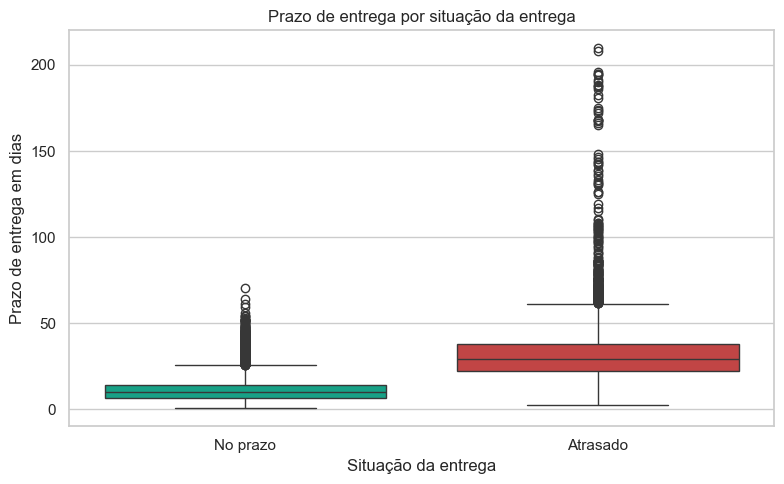

In [64]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=delivered_df.assign(
        situacao_entrega=delivered_df["entrega_atrasada"].map({
            False: "No prazo",
            True: "Atrasado"
        })
    ),
    x="situacao_entrega",
    y="prazo_entrega_dias",
    palette=["#00b894", "#d63031"]
)

plt.title("Prazo de entrega por situação da entrega")
plt.xlabel("Situação da entrega")
plt.ylabel("Prazo de entrega em dias")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera um boxplot comparando a distribuição do prazo de entrega entre pedidos no prazo e atrasados.

Leitura para estudo
O boxplot ajuda a ver:

mediana
dispersão
presença de valores extremos
Leitura para o relatório
Esse gráfico reforça que pedidos atrasados não apenas recebem pior nota, mas também apresentam uma distribuição de prazo bem mais longa e instável.

## 66. Criando uma síntese textual da análise logística

Agora vamos montar uma leitura resumida com base nos resultados encontrados.

In [65]:
print(
    "A operação apresenta prazo médio de entrega de",
    round(delivered_df["prazo_entrega_dias"].mean(), 2),
    "dias e taxa de atraso de",
    round(delivered_df["entrega_atrasada"].mean() * 100, 2),
    "%."
)

print(
    "Pedidos no prazo têm nota média de",
    round(nota_no_prazo, 2),
    "enquanto pedidos atrasados têm nota média de",
    round(nota_atrasado, 2),
    "."
)

A operação apresenta prazo médio de entrega de 12.56 dias e taxa de atraso de 8.11 %.
Pedidos no prazo têm nota média de 4.29 enquanto pedidos atrasados têm nota média de 2.57 .


O que esta etapa gera
Cria uma síntese textual curta da análise logística.

Leitura para estudo
Essa prática ajuda a transformar análise em comunicação.

Leitura para o relatório
Essa síntese pode ser adaptada quase diretamente para o texto da seção de logística do trabalho.



## 67. Considerações executivas da fase 7

A análise logística mostra que a maior parte da operação é concluída de forma satisfatória, mas existe um volume relevante de pedidos atrasados.

O ponto mais importante, porém, não é apenas a existência do atraso, mas o seu efeito sobre a experiência do cliente.

Os dados mostram que pedidos atrasados recebem avaliações muito inferiores aos pedidos entregues no prazo, evidenciando que a performance logística é um dos principais determinantes da satisfação no e-commerce.

Do ponto de vista executivo, isso significa que logística não deve ser tratada apenas como área operacional ou centro de custo. Ela é, na prática, uma alavanca estratégica de retenção, reputação e geração de valor.

Fechamento da Parte 7
Ao final desta fase, você terá:

indicadores logísticos centrais
histograma do prazo de entrega
histograma do atraso em relação ao prazo estimado
tabela comparando pedidos no prazo e atrasados
gráfico do impacto do atraso na satisfação
boxplot do prazo por situação da entrega
uma leitura executiva muito forte sobre SLA e experiência do cliente
Essa parte é uma das mais poderosas de todo o notebook e provavelmente será um dos pilares do seu relatório.



 que vem na Parte 8
Agora o próximo passo natural é entrar em:

Parte 8 — Meios de pagamento e comportamento transacional
Nessa fase, vamos analisar:

quais meios de pagamento dominam a operação
quanto cada meio movimenta financeiramente
comportamento de parcelamento
como isso pode ser interpretado do ponto de vista de negócio


Parte 8 — Meios de pagamento e comportamento transacional

## 68. Início da análise de meios de pagamento

Depois de entender o crescimento comercial, a concentração de receita, a geografia da operação e o impacto logístico na satisfação, vamos agora analisar os meios de pagamento.

Essa etapa ajuda a responder perguntas como:
- quais meios de pagamento são mais utilizados
- quanto cada meio movimenta financeiramente
- qual é o peso do cartão de crédito no negócio
- como o comportamento de parcelamento pode ser interpretado

Do ponto de vista executivo, essa análise complementa a leitura comercial e ajuda a entender o perfil transacional da base.

In [66]:
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


O que esta etapa gera
Mostra uma amostra da tabela de pagamentos.

Leitura para estudo
Antes de agregar os dados, sempre vale relembrar a estrutura da tabela.

Aqui aparecem colunas como:

order_id
payment_type
payment_installments
payment_value

Leitura para o relatório
Essa tabela será a base para entender o comportamento de pagamento dos clientes.



## 69. Consolidando o valor transacionado por meio de pagamento

Agora vamos agrupar os dados de pagamento para descobrir quanto cada meio movimentou financeiramente.

In [67]:
payment_mix_df = (
    payments_df.groupby("payment_type", as_index=False)
    .agg(
        quantidade_pagamentos=("order_id", "count"),
        valor_total=("payment_value", "sum"),
        parcelas_medias=("payment_installments", "mean")
    )
    .sort_values("valor_total", ascending=False)
)

payment_mix_df

,payment_type,quantidade_pagamentos,valor_total,parcelas_medias
1,credit_card,76795,12542084.19,3.507155
0,boleto,19784,2869361.27,1.000000
4,voucher,5775,379436.87,1.000000
2,debit_card,1529,217989.79,1.000000
3,not_defined,3,0.00,1.000000


O que esta etapa gera
Cria a tabela payment_mix_df, com três medidas principais por meio de pagamento:

quantidade_pagamentos
quantidade de registros de pagamento

valor_total
valor financeiro movimentado

parcelas_medias
número médio de parcelas

Leitura para estudo
Aqui você está consolidando a tabela de pagamentos para transformá-la em uma visão gerencial.
Leitura para o relatório
Essa tabela permite identificar:

o meio dominante
o peso relativo de cada opção
o comportamento médio de parcelamento
Normalmente, o cartão de crédito aparece com grande predominância.

## 70. Observando o ranking dos meios de pagamento

Agora vamos olhar o ranking em ordem decrescente de valor transacionado.

In [68]:
payment_mix_df

,payment_type,quantidade_pagamentos,valor_total,parcelas_medias
1,credit_card,76795,12542084.19,3.507155
0,boleto,19784,2869361.27,1.000000
4,voucher,5775,379436.87,1.000000
2,debit_card,1529,217989.79,1.000000
3,not_defined,3,0.00,1.000000


O que esta etapa gera
Mostra o ranking completo dos meios de pagamento por valor movimentado.

Leitura para estudo
Esse ranking permite comparar, de forma simples, o peso financeiro de:

cartão de crédito
boleto
voucher
débito
outras categorias eventuais
Leitura para o relatório
A interpretação executiva tende a ser algo como:

O cartão de crédito concentra a maior parte do valor transacionado da operação, seguido por boleto, o que sugere forte dependência de meios de pagamento tradicionais e predominância de compras financiadas ou parceladas.

## 71. Gráfico de valor transacionado por meio de pagamento

Agora vamos visualizar essa distribuição em um gráfico de barras.

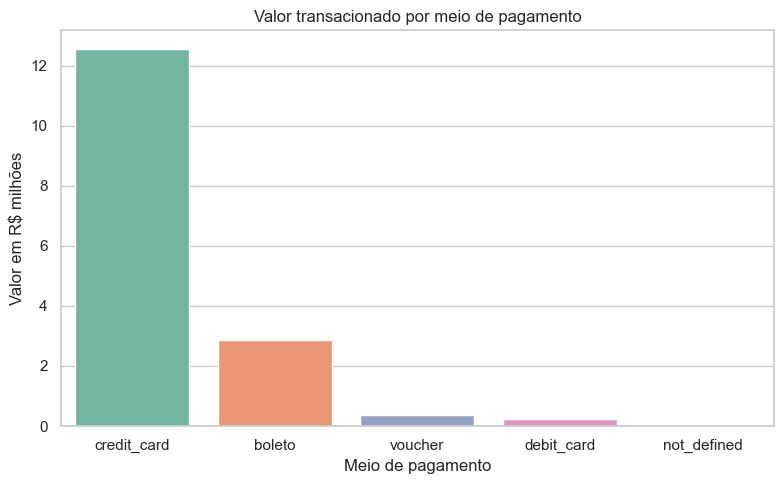

In [69]:
payment_plot_df = payment_mix_df.copy()
payment_plot_df["valor_milhoes"] = payment_plot_df["valor_total"] / 1000000

plt.figure(figsize=(8, 5))

sns.barplot(
    data=payment_plot_df,
    x="payment_type",
    y="valor_milhoes",
    hue="payment_type",
    dodge=False,
    palette="Set2",
    legend=False
)

plt.title("Valor transacionado por meio de pagamento")
plt.xlabel("Meio de pagamento")
plt.ylabel("Valor em R$ milhões")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Valor transacionado por meio de pagamento.

Leitura para estudo
Esse gráfico facilita muito a comparação visual entre os meios de pagamento.

Leitura para o relatório
A leitura executiva é direta:

O cartão de crédito domina amplamente o volume financeiro da operação, enquanto boleto aparece como segunda principal alternativa. Os demais meios têm participação significativamente menor.



## 72. Calculando a participação percentual de cada meio de pagamento

Agora vamos transformar os valores absolutos em participação relativa.

In [70]:
payment_mix_df["participacao_valor"] = (
    payment_mix_df["valor_total"] / payment_mix_df["valor_total"].sum()
)

payment_mix_df

,payment_type,quantidade_pagamentos,valor_total,parcelas_medias,participacao_valor
1,credit_card,76795,12542084.19,3.507155,0.783446
0,boleto,19784,2869361.27,1.000000,0.179236
4,voucher,5775,379436.87,1.000000,0.023702
2,debit_card,1529,217989.79,1.000000,0.013617
3,not_defined,3,0.00,1.000000,0.000000


O que esta etapa gera
Cria a coluna participacao_valor, que mostra o peso percentual de cada meio no valor total transacionado.

Leitura para estudo
Essa etapa é útil porque porcentagens costumam comunicar melhor do que valores absolutos isolados.

Leitura para o relatório
Com isso, você consegue escrever frases como:

O cartão de crédito responde pela maior parcela do valor transacionado, reforçando seu papel central na jornada de compra do cliente.

## 73. Destacando a participação do cartão de crédito

Como o cartão tende a liderar com bastante folga, vale medir sua participação de forma isolada.

In [71]:
participacao_credito = payment_mix_df.loc[
    payment_mix_df["payment_type"] == "credit_card",
    "participacao_valor"
].values[0]

print("Participação do cartão de crédito no valor total:", round(participacao_credito * 100, 2), "%")

Participação do cartão de crédito no valor total: 78.34 %


O que esta etapa gera
Calcula a participação percentual do cartão de crédito no valor total transacionado.

Leitura para estudo
Esse tipo de cálculo ajuda a destacar o elemento dominante dentro de um ranking.

Leitura para o relatório
Executivamente, isso reforça uma mensagem importante:

A operação apresenta forte dependência do cartão de crédito como principal meio de pagamento, o que sugere que a experiência de compra está fortemente apoiada em conveniência, parcelamento e financiamento do consumo.



## 74. Observando o comportamento de parcelamento

Agora vamos olhar a média de parcelas por meio de pagamento.

In [72]:
payment_mix_df[["payment_type", "parcelas_medias"]]

,payment_type,parcelas_medias
1,credit_card,3.507155
0,boleto,1.000000
4,voucher,1.000000
2,debit_card,1.000000
3,not_defined,1.000000


O que esta etapa gera
Mostra a média de parcelas para cada meio de pagamento.

Leitura para estudo
Essa análise ajuda a entender se o parcelamento está concentrado principalmente no cartão, como geralmente se espera.

Leitura para o relatório
Se o cartão aparecer com média de parcelas significativamente superior aos demais meios, isso ajuda a reforçar a tese de uso intenso de crédito parcelado.

## 75. Distribuição do número de parcelas no cartão de crédito

Como o cartão de crédito é o meio dominante, vale detalhar melhor como o parcelamento se distribui dentro dele.

In [73]:
credit_card_df = payments_df[payments_df["payment_type"] == "credit_card"].copy()

credit_installments_df = (
    credit_card_df.groupby("payment_installments", as_index=False)
    .agg(
        quantidade_pagamentos=("order_id", "count"),
        valor_total=("payment_value", "sum")
    )
    .sort_values("payment_installments")
)

credit_installments_df.head(15)

,payment_installments,quantidade_pagamentos,valor_total
0,0,2,188.63
1,1,25455,2440445.43
2,2,12413,1579283.03
3,3,10461,1491103.80
4,4,7098,1163907.61
5,5,5239,961174.30
6,6,3920,822611.81
7,7,1626,305157.39
8,8,4268,1313423.34
9,9,644,131015.92


O que esta etapa gera
Cria a tabela credit_installments_df, mostrando:

número de parcelas
quantidade de pagamentos
valor transacionado
para os pagamentos em cartão de crédito.

Leitura para estudo
Esse passo aprofunda a análise dentro do meio de pagamento mais importante.

Leitura para o relatório
Ele ajuda a entender se a operação depende mais de compras à vista no cartão ou de parcelamento mais longo.

## 76. Gráfico da distribuição de parcelas no cartão de crédito

Agora vamos visualizar como o número de parcelas se distribui entre os pagamentos com cartão.

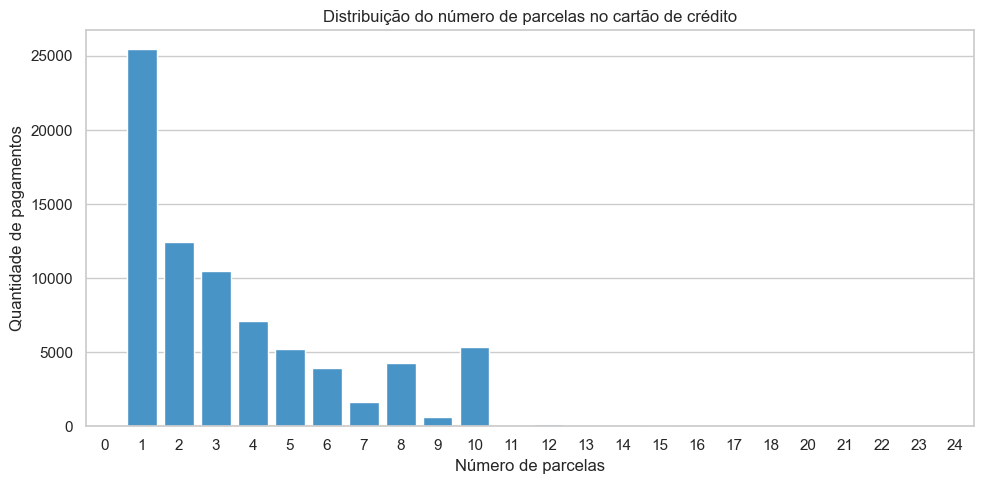

In [74]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=credit_installments_df,
    x="payment_installments",
    y="quantidade_pagamentos",
    color="#3498db"
)

plt.title("Distribuição do número de parcelas no cartão de crédito")
plt.xlabel("Número de parcelas")
plt.ylabel("Quantidade de pagamentos")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Distribuição do número de parcelas no cartão de crédito.

Leitura para estudo
Esse gráfico ajuda a identificar as faixas de parcelamento mais comuns.

Leitura para o relatório
A leitura executiva possível é:

A predominância do cartão de crédito, combinada à presença relevante de compras parceladas, sugere um perfil de consumo apoiado em flexibilidade de pagamento, o que pode ser importante para sustentar conversão e ticket médio.



## 77. Comparando meios de pagamento em quantidade de registros

Além do valor financeiro, também é útil comparar a frequência de uso de cada meio.

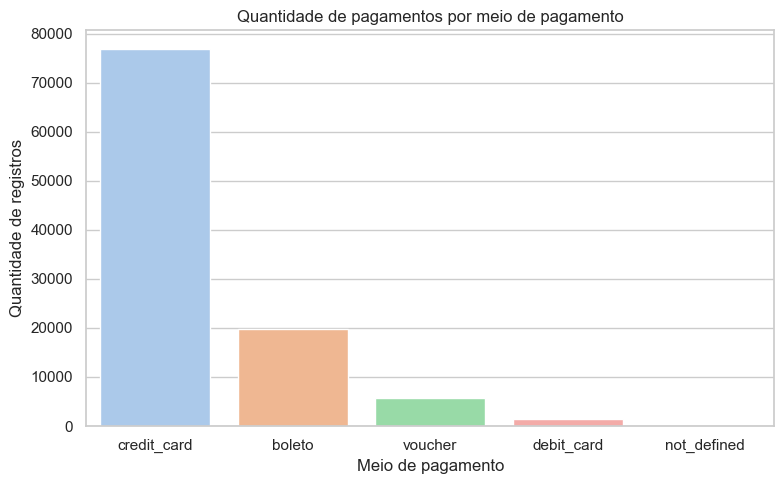

In [75]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=payment_mix_df,
    x="payment_type",
    y="quantidade_pagamentos",
    hue="payment_type",
    dodge=False,
    palette="pastel",
    legend=False
)

plt.title("Quantidade de pagamentos por meio de pagamento")
plt.xlabel("Meio de pagamento")
plt.ylabel("Quantidade de registros")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Quantidade de pagamentos por meio de pagamento.

Leitura para estudo
Às vezes, um meio pode aparecer com menor valor, mas com frequência alta. Comparar quantidade e valor ajuda a entender melhor o perfil transacional.

Leitura para o relatório
Esse gráfico ajuda a reforçar se o cartão lidera tanto em frequência quanto em valor, o que fortalece a leitura de dominância transacional.



## 78. Considerações executivas da fase 8

A análise dos meios de pagamento mostra que o cartão de crédito ocupa posição claramente dominante na operação, tanto em valor transacionado quanto em frequência de uso.

O boleto aparece como segunda alternativa relevante, enquanto os demais meios têm participação bem menor.

Do ponto de vista executivo, isso indica que a jornada comercial da Olist está fortemente apoiada em meios de pagamento tradicionais, com destaque para a conveniência e o parcelamento oferecidos pelo cartão de crédito.

Essa leitura é importante porque sugere que a conversão da operação depende, em boa medida, de uma experiência de pagamento fluida, confiável e compatível com o comportamento de consumo parcelado do cliente brasileiro.

Fechamento da Parte 8
Ao final desta fase, você terá:

a tabela consolidada dos meios de pagamento
o gráfico de valor transacionado por meio de pagamento
a participação percentual de cada meio
a participação do cartão de crédito
a análise do parcelamento no cartão
o gráfico de distribuição das parcelas
o gráfico de quantidade de pagamentos por meio
Essa parte complementa bem a leitura comercial e ajuda a enriquecer o relatório com uma visão de comportamento transacional.

O que vem na Parte 9
O próximo passo natural é entrar em:

Parte 9 — Recorrência, recompra e relacionamento com o cliente
Nessa fase, vamos analisar:

quantos clientes únicos existem
quantos voltaram a comprar
taxa de recompra
o que isso significa para retenção e valor de longo prazo

Parte 9 — Recorrência, recompra e relacionamento com o cliente

## 79. Início da análise de recorrência

Depois de analisar crescimento, portfólio, geografia, logística e meios de pagamento, vamos agora observar o comportamento dos clientes ao longo do tempo.

Nesta etapa, o objetivo é entender se a operação se apoia apenas em aquisição de novos pedidos ou se também apresenta sinais de recompra.

Essa análise é importante porque ajuda a responder:
- quantos clientes únicos existem na base
- quantos clientes compraram mais de uma vez
- qual é a taxa de recompra
- o que isso pode indicar sobre retenção e relacionamento com o cliente

Do ponto de vista executivo, essa leitura ajuda a avaliar o potencial de geração de valor no longo prazo.

In [76]:
clientes_unicos = delivered_df["customer_unique_id"].nunique()
clientes_unicos

93358

O que esta etapa gera
Calcula a quantidade de clientes únicos na base de pedidos entregues.

Leitura para estudo
A tabela de clientes da Olist tem duas chaves importantes:

customer_id
customer_unique_id
O campo mais adequado para analisar recorrência é o customer_unique_id, porque ele representa o cliente de forma consolidada, mesmo que existam múltiplos registros operacionais.

Leitura para o relatório
Esse número representa a base efetiva de clientes atendidos e é o ponto de partida para medir recompra.

## 80. Calculando o número de pedidos por cliente

Agora vamos agrupar os dados por cliente único para descobrir quantos pedidos cada cliente realizou.

In [77]:
customer_orders_df = delivered_df.groupby("customer_unique_id", as_index=False).agg(
    quantidade_pedidos=("order_id", "nunique"),
    receita_total=("receita", "sum"),
    ticket_medio_cliente=("receita", "mean"),
    nota_media_cliente=("review_score", "mean")
)

customer_orders_df.head()

,customer_unique_id,quantidade_pedidos,receita_total,ticket_medio_cliente,nota_media_cliente
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,129.90,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,18.90,4.0
2,0000f46a3911fa3c0805444483337064,1,69.00,69.00,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,25.99,4.0
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,180.00,5.0


O que esta etapa gera
Cria a tabela customer_orders_df, com um resumo por cliente.

Ela traz:

quantidade de pedidos
receita total por cliente
ticket médio do cliente
nota média de avaliação do cliente
Leitura para estudo
Aqui você está trocando a unidade de análise novamente.
Em vez de olhar para pedidos, meses ou estados, agora o foco passa a ser o cliente.

Leitura para o relatório
Essa tabela é a base para entender se a operação tem sinais de retenção ou se depende majoritariamente de compra única.

## 81. Distribuição da quantidade de pedidos por cliente

Agora vamos observar quantos clientes fizeram apenas uma compra e quantos fizeram múltiplas compras.

In [78]:
distribuicao_pedidos_cliente_df = (
    customer_orders_df.groupby("quantidade_pedidos", as_index=False)
    .agg(clientes=("customer_unique_id", "count"))
    .sort_values("quantidade_pedidos")
)

distribuicao_pedidos_cliente_df.head(10)

,quantidade_pedidos,clientes
0,1,90557
1,2,2573
2,3,181
3,4,28
4,5,9
5,6,5
6,7,3
7,9,1
8,15,1


O que esta etapa gera
Mostra quantos clientes estão em cada faixa de quantidade de pedidos.

Leitura para estudo
Essa distribuição ajuda a perceber rapidamente se a base é mais concentrada em compra única ou em recorrência.

Leitura para o relatório
Se a maior parte dos clientes tiver apenas um pedido, isso sugere uma operação ainda mais orientada à aquisição do que à retenção.

## 82. Calculando clientes com recompra

Vamos agora medir quantos clientes fizeram dois ou mais pedidos.

In [79]:
clientes_recompra = (customer_orders_df["quantidade_pedidos"] >= 2).sum()
taxa_recompra = clientes_recompra / clientes_unicos

print("Clientes únicos:", clientes_unicos)
print("Clientes com 2 ou mais pedidos:", int(clientes_recompra))
print("Taxa de recompra:", round(taxa_recompra * 100, 2), "%")

Clientes únicos: 93358
Clientes com 2 ou mais pedidos: 2801
Taxa de recompra: 3.0 %


O que esta etapa gera
Calcula:

total de clientes únicos
total de clientes com recompra
taxa de recompra
Com base na análise anterior, o valor esperado da taxa de recompra deve ficar perto de 3,12%.

Leitura para estudo
Essa é uma métrica simples, mas muito importante.

Ela não mede retenção completa nem coorte, mas já oferece um bom primeiro indicador de recorrência.

Leitura para o relatório
Esse resultado costuma gerar uma leitura importante:

A operação mostra boa capacidade de aquisição, mas a taxa de recompra ainda é baixa, sugerindo que existe espaço relevante para evolução em retenção e relacionamento com o cliente.

## 83. Organizando os indicadores de recorrência em uma tabela resumo

Agora vamos consolidar os principais números de recorrência em uma pequena tabela.

In [80]:
resumo_recorrencia_df = pd.DataFrame({
    "indicador": [
        "Clientes únicos",
        "Clientes com 2 ou mais pedidos",
        "Taxa de recompra"
    ],
    "valor": [
        clientes_unicos,
        int(clientes_recompra),
        taxa_recompra
    ]
})

resumo_recorrencia_df

,indicador,valor
0,Clientes únicos,93358.000000
1,Clientes com 2 ou mais pedidos,2801.000000
2,Taxa de recompra,0.030003


O que esta etapa gera
Cria uma tabela resumo com os principais indicadores de recorrência.

Leitura para estudo
Organizar os números em tabela facilita interpretação e reaproveitamento posterior.

Leitura para o relatório
Essa tabela pode virar diretamente uma subseção da análise de relacionamento com o cliente.



## 84. Gráfico da distribuição de clientes por quantidade de pedidos

Agora vamos visualizar a distribuição da base entre clientes com compra única e clientes com recorrência.

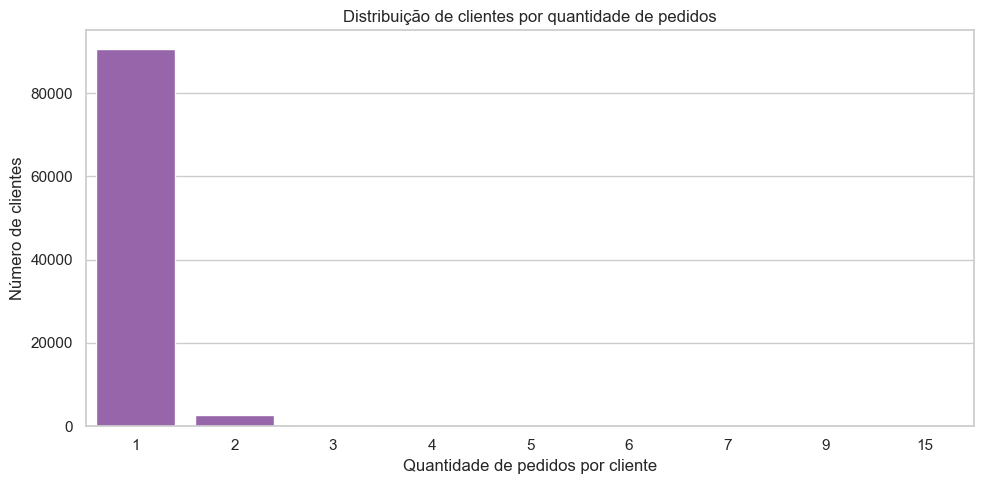

In [81]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=distribuicao_pedidos_cliente_df.head(10),
    x="quantidade_pedidos",
    y="clientes",
    color="#9b59b6"
)

plt.title("Distribuição de clientes por quantidade de pedidos")
plt.xlabel("Quantidade de pedidos por cliente")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Distribuição de clientes por quantidade de pedidos.

Leitura para estudo
Esse gráfico costuma mostrar uma concentração muito forte em clientes com apenas um pedido.

Leitura para o relatório
Esse é um gráfico útil para mostrar visualmente que a base é majoritariamente composta por clientes de compra única.



## 85. Comparando clientes de compra única e clientes recorrentes

Agora vamos separar os clientes em dois grupos:
- clientes com apenas um pedido
- clientes com dois ou mais pedidos

Depois vamos comparar receita média por cliente e ticket médio.

In [82]:
customer_orders_df["perfil_cliente"] = customer_orders_df["quantidade_pedidos"].apply(
    lambda quantidade: "Recorrente" if quantidade >= 2 else "Compra única"
)

perfil_cliente_df = customer_orders_df.groupby("perfil_cliente", as_index=False).agg(
    clientes=("customer_unique_id", "count"),
    receita_media_cliente=("receita_total", "mean"),
    ticket_medio_cliente=("ticket_medio_cliente", "mean"),
    nota_media_cliente=("nota_media_cliente", "mean")
)

perfil_cliente_df

,perfil_cliente,clientes,receita_media_cliente,ticket_medio_cliente,nota_media_cliente
0,Compra única,90557,138.049829,137.958295,4.152029
1,Recorrente,2801,277.921528,123.150033,4.206487


O que esta etapa gera
Cria a tabela perfil_cliente_df, comparando:

quantidade de clientes
receita média por cliente
ticket médio por cliente
nota média por cliente
entre os grupos:

compra única
recorrente
Leitura para estudo
Essa segmentação é muito útil porque permite comparar grupos de clientes com comportamentos diferentes.

Leitura para o relatório
Em geral, clientes recorrentes tendem a gerar mais receita acumulada por cliente, o que reforça a importância da retenção na geração de valor de longo prazo.

## 86. Gráfico de receita média por perfil de cliente

Vamos visualizar agora a diferença de receita média entre clientes recorrentes e clientes de compra única.

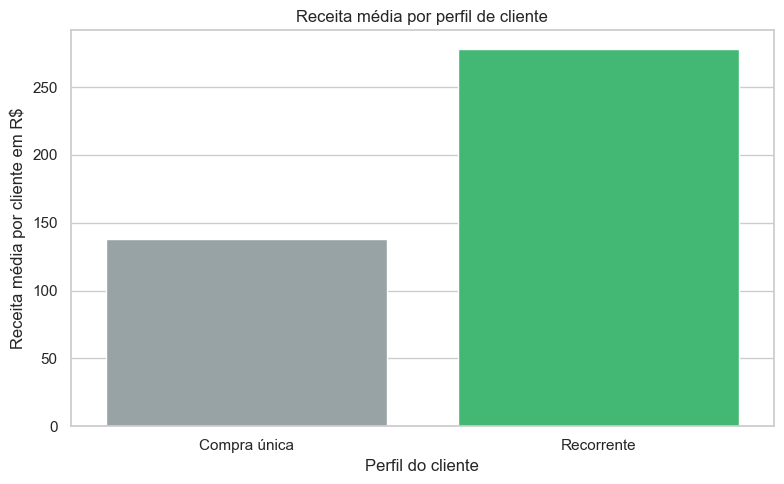

In [83]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=perfil_cliente_df,
    x="perfil_cliente",
    y="receita_media_cliente",
    hue="perfil_cliente",
    dodge=False,
    palette=["#95a5a6", "#2ecc71"],
    legend=False
)

plt.title("Receita média por perfil de cliente")
plt.xlabel("Perfil do cliente")
plt.ylabel("Receita média por cliente em R$")
plt.tight_layout()
plt.show()

O que esta etapa gera
Gera o gráfico Receita média por perfil de cliente.

Leitura para estudo
Esse gráfico ajuda a visualizar o valor acumulado por cliente em cada grupo.

Leitura para o relatório
Ele normalmente reforça a leitura de que clientes recorrentes têm valor econômico superior, justificando investimentos em retenção, CRM e pós-venda.

## 87. Avaliando a participação da base recorrente na receita total

Agora vamos medir quanto da receita total vem de clientes recorrentes.

In [84]:
receita_por_perfil_df = customer_orders_df.groupby("perfil_cliente", as_index=False).agg(
    receita_total=("receita_total", "sum")
)

receita_total_clientes = receita_por_perfil_df["receita_total"].sum()
receita_recorrentes = receita_por_perfil_df.loc[
    receita_por_perfil_df["perfil_cliente"] == "Recorrente",
    "receita_total"
].values[0]

participacao_receita_recorrentes = receita_recorrentes / receita_total_clientes

print("Receita total de clientes recorrentes:", round(receita_recorrentes, 2))
print("Participação dos clientes recorrentes na receita total:", round(participacao_receita_recorrentes * 100, 2), "%")

Receita total de clientes recorrentes: 778458.2
Participação dos clientes recorrentes na receita total: 5.86 %


O que esta etapa gera
Calcula quanto da receita total está associada a clientes recorrentes.

Leitura para estudo
Essa análise é boa porque mostra que, mesmo sendo minoria em quantidade, clientes recorrentes podem ter peso desproporcional em receita.

Leitura para o relatório
Se essa participação for relevante, isso reforça uma tese muito importante:

Mesmo representando parcela pequena da base, clientes recorrentes podem concentrar valor econômico relevante, o que reforça a importância estratégica da retenção.

## 88. Observando os clientes com maior quantidade de pedidos

Agora vamos olhar os clientes mais recorrentes da base.

In [85]:
customer_orders_df.sort_values("quantidade_pedidos", ascending=False).head(10)

,customer_unique_id,quantidade_pedidos,receita_total,ticket_medio_cliente,nota_media_cliente,perfil_cliente
51431,8d50f5eadf50201ccdcedfb9e2ac8455,15,714.63,47.642000,5.000000,Recorrente
22779,3e43e6105506432c953e165fb2acf44c,9,1000.85,111.205556,2.777778,Recorrente
36706,6469f99c1f9dfae7733b25662e7f1782,7,664.20,94.885714,5.000000,Recorrente
10060,1b6c7548a2a1f9037c1fd3ddfed95f33,7,809.21,115.601429,5.000000,Recorrente
73921,ca77025e7201e3b30c44b472ff346268,7,806.61,115.230000,5.000000,Recorrente
26257,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,874.60,124.942857,4.857143,Recorrente
80538,dc813062e0fc23409cd255f7f53c7074,6,687.76,114.626667,4.500000,Recorrente
36500,63cfc61cee11cbe306bff5857d00bfe4,6,579.81,96.635000,4.500000,Recorrente
87885,f0e310a6839dce9de1638e0fe5ab282a,6,438.09,73.015000,4.500000,Recorrente
6964,12f5d6e1cbf93dafd9dcc19095df0b3d,6,58.40,9.733333,5.000000,Recorrente


O que esta etapa gera
Mostra os clientes com maior número de pedidos.

Leitura para estudo
Essa etapa ajuda a enxergar extremos dentro da base de recorrência.

Leitura para o relatório
Embora não seja a parte central do relatório executivo, isso ajuda a confirmar que existe um grupo pequeno, porém mais engajado, dentro da base.

## 89. Considerações executivas da fase 9

A análise de recorrência mostra que a operação da Olist apresenta forte concentração em clientes de compra única, com taxa de recompra relativamente baixa.

Do ponto de vista executivo, isso sugere que o negócio demonstra boa capacidade de aquisição e geração de volume, mas ainda possui espaço importante para amadurecer sua estratégia de retenção.

Essa leitura é especialmente relevante porque clientes recorrentes tendem a gerar mais valor acumulado ao longo do tempo.

Assim, melhorar a experiência do cliente, reduzir fricções logísticas e desenvolver ações de relacionamento pode representar uma oportunidade concreta de elevar o valor de longo prazo da base.

Fechamento da Parte 9
Ao final desta fase, você terá:

o total de clientes únicos
a taxa de recompra
a tabela resumo de recorrência
o gráfico de distribuição de pedidos por cliente
a comparação entre clientes recorrentes e de compra única
o gráfico de receita média por perfil de cliente
a participação da base recorrente na receita total
Essa parte fecha muito bem a dimensão de relacionamento com o cliente e ajuda a trazer a discussão de valor no longo prazo.

O que vem na Parte 10
O próximo passo natural é entrar em:

Parte 10 — Consolidação final do relatório executivo
Nessa fase, vamos organizar:

os principais achados
as mensagens executivas centrais
as conclusões
as recomendações estratégicas
um texto final pronto para usar no relatório


Parte 10 — Consolidação final do relatório executivo


## 90. Consolidação da análise executiva

Ao longo deste notebook, foram analisadas diferentes dimensões da operação da Olist:
- crescimento comercial
- receita e ticket médio
- categorias de produto
- concentração regional
- eficiência logística
- satisfação do cliente
- meios de pagamento
- recorrência de clientes

Agora, o objetivo é consolidar os principais achados em uma narrativa executiva clara e orientada a decisão.

Nesta etapa final, vamos organizar os resultados em forma de:
- mensagens centrais
- conclusões
- recomendações estratégicas
- texto-base para o relatório executivo

## 91. Principais mensagens executivas do estudo

Com base nas análises realizadas, emergem cinco mensagens centrais.

### 1. A operação apresentou crescimento comercial relevante
A evolução mensal de pedidos e receita mostrou forte expansão da operação ao longo do período analisado, indicando ganho de escala e tração do marketplace.

### 2. A geração de valor é concentrada em categorias e estados específicos
O faturamento não está distribuído de maneira homogênea. Algumas categorias líderes e alguns estados, especialmente São Paulo, concentram parcela muito relevante da receita.

### 3. A logística é um fator decisivo para a experiência do cliente
O atraso na entrega impacta fortemente a satisfação, mostrando que eficiência operacional não é apenas tema de custo, mas de percepção de valor.

### 4. O cartão de crédito domina a jornada transacional
A operação depende fortemente do cartão como principal meio de pagamento, o que sugere relevância de conveniência, parcelamento e experiência de checkout.

### 5. Há espaço importante para evoluir em retenção
A taxa de recompra observada é baixa, o que sugere uma operação ainda mais forte em aquisição do que em recorrência.

O que esta etapa gera
Essa célula organiza os principais achados da análise em linguagem executiva.

Leitura para estudo
Aqui você está aprendendo a fazer uma das coisas mais importantes em dados: sintetizar.

Não basta ter vários gráficos e tabelas. Você precisa extrair as mensagens que realmente importam.

Leitura para o relatório
Essa célula praticamente já vira uma seção chamada “Principais achados”.



## 92. Conclusões estratégicas

A análise indica que a Olist já demonstrava capacidade real de crescimento e consolidação comercial no período observado.

O negócio apresenta tração, volume transacional relevante e categorias com forte capacidade de monetização. No entanto, os dados também mostram que o crescimento não se distribui de forma uniforme entre categorias, regiões e experiências de cliente.

O principal ponto de atenção da operação está na consistência logística. Os atrasos, embora não dominem a operação, têm impacto significativo na satisfação do cliente, o que pode afetar reputação, retenção e valor de longo prazo.

Além disso, a baixa taxa de recompra sugere que a empresa possui oportunidade concreta de capturar mais valor da base atual, reduzindo a dependência exclusiva de aquisição.

Em síntese, a Olist mostrou capacidade de crescer. O próximo salto de valor depende de transformar eficiência operacional em recorrência, confiança e fidelização.

O que esta etapa gera
Essa célula constrói o bloco de conclusões estratégicas do relatório.

Leitura para estudo
Aqui você está juntando várias análises separadas em uma visão integrada do negócio.

Leitura para o relatório
Esse texto pode entrar quase diretamente na seção de Conclusões.



## 93. Recomendações estratégicas

Com base nos resultados encontrados, algumas recomendações se destacam.

### Priorizar a redução de atrasos logísticos
Como a satisfação cai fortemente quando a entrega atrasa, reduzir atrasos deve ser tratado como prioridade estratégica.

### Replicar práticas operacionais dos mercados mais eficientes
Estados com melhor combinação entre prazo e satisfação podem funcionar como referência para melhorias em regiões com maior fricção.

### Concentrar investimento nas categorias líderes
As categorias de maior receita devem receber atenção especial em sortimento, marketing, precificação e disponibilidade.

### Desenvolver uma agenda de retenção e recompra
A baixa taxa de recompra indica espaço para ações de CRM, relacionamento e pós-venda.

### Monitorar a jornada de pagamento como alavanca de conversão
A forte dependência do cartão de crédito sugere que qualquer fricção nessa etapa pode afetar diretamente o desempenho comercial.

O que esta etapa gera
Essa célula reúne as recomendações executivas do trabalho.

Leitura para estudo
Uma boa análise não termina só em diagnóstico. Ela precisa apontar o que fazer com o achado.

Leitura para o relatório
Essa parte é perfeita para fechar o relatório com foco em ação.

## 94. Texto-base para o sumário executivo

A análise da base pública da Olist indica uma operação com forte crescimento comercial entre 2016 e 2018, sustentada por categorias líderes e forte concentração regional em mercados como São Paulo.

Os dados mostram que a empresa alcançou escala relevante em pedidos e receita, com ticket médio consistente e boa avaliação média do cliente. No entanto, também revelam que a eficiência logística é o principal fator crítico para sustentar valor no médio e longo prazo.

Pedidos entregues no prazo mantêm níveis elevados de satisfação, enquanto pedidos atrasados sofrem queda expressiva de avaliação. Isso demonstra que logística não deve ser tratada apenas como operação de suporte, mas como parte central da proposta de valor do e-commerce.

Além disso, a análise de recorrência sugere que a empresa ainda possui espaço importante para evoluir em retenção, o que abre oportunidade para aumentar o valor da base atual de clientes.

Em termos executivos, a principal conclusão é clara: a Olist já provou que consegue crescer. O próximo ciclo de geração de valor dependerá da capacidade de transformar eficiência operacional em fidelização, reputação e vantagem competitiva.

O que esta etapa gera
Essa célula cria um texto-base pronto para o sumário executivo.

Leitura para estudo
Isso mostra como transformar análise em texto corrido de alto nível.

Leitura para o relatório
Essa célula pode ser usada praticamente como está na abertura do trabalho.



## 95. Estrutura sugerida para o relatório final

Uma forma recomendada de organizar o relatório é a seguinte.

### 1. Introdução
Apresentar o contexto do Tech Challenge e o objetivo da análise.

### 2. Base de dados e metodologia
Explicar quais tabelas foram utilizadas, como a base foi integrada e quais métricas foram construídas.

### 3. Principais indicadores
Mostrar os KPIs executivos principais.

### 4. Crescimento comercial
Apresentar evolução de receita, pedidos e ticket médio.

### 5. Portfólio e categorias
Mostrar as categorias líderes e a concentração de receita.

### 6. Geografia e operação
Apresentar receita por estado, prazo médio e satisfação regional.

### 7. Logística e experiência do cliente
Mostrar o impacto do atraso na satisfação.

### 8. Meios de pagamento e recorrência
Complementar a visão com comportamento transacional e recompra.

### 9. Conclusões e recomendações
Fechar com mensagens executivas e propostas de ação.

O que esta etapa gera
Essa célula organiza a estrutura final recomendada do relatório.

Leitura para estudo
Essa é uma etapa de organização narrativa, não de cálculo.

Leitura para o relatório
Ela serve como guia para montar a versão final em Word, PDF ou apresentação.



## 96. Estrutura sugerida para a apresentação executiva

A apresentação executiva pode ser organizada em aproximadamente 8 a 10 slides.

### Slide 1. Título
Tech Challenge - Olist: crescimento, eficiência e oportunidades de valor

### Slide 2. Sumário executivo
Trazer as 3 ou 4 mensagens centrais do estudo

### Slide 3. Principais indicadores
Pedidos, receita, ticket médio, prazo médio, nota média e taxa de atraso

### Slide 4. Crescimento comercial
Gráficos de evolução mensal da receita e dos pedidos

### Slide 5. Categorias líderes
Top categorias por receita

### Slide 6. Geografia da operação
Receita por estado e prazo versus satisfação

### Slide 7. Logística e experiência
Impacto do atraso na satisfação

### Slide 8. Pagamentos e recorrência
Mix de pagamento e taxa de recompra

### Slide 9. Recomendações estratégicas
Lista objetiva de ações recomendadas

### Slide 10. Encerramento
Mensagem final: crescer com eficiência será a principal alavanca de valor

 que esta etapa gera
Essa célula cria o esqueleto da apresentação executiva.

Leitura para estudo
Você está aprendendo a transformar notebook em apresentação.

Leitura para o relatório
Essa estrutura ajuda muito no vídeo e na defesa do trabalho.



## 97. Mensagem final do estudo

A Olist já demonstrou capacidade de expansão comercial, com crescimento de receita, avanço do volume de pedidos e presença relevante em múltiplas categorias e regiões.

No entanto, os dados mostram que o valor futuro do negócio dependerá menos de simplesmente vender mais e mais da capacidade de crescer com consistência operacional.

A redução de atrasos, a melhoria da experiência do cliente e o fortalecimento da retenção aparecem como as principais alavancas para transformar crescimento em geração de valor sustentável.

O que esta etapa gera
Essa célula cria uma mensagem final de encerramento.

Leitura para estudo
Esse tipo de parágrafo é importante porque fecha a narrativa com clareza.

Leitura para o relatório
Pode ser usado no último parágrafo do relatório ou no último slide da apresentação.



## 98. Considerações finais sobre o notebook

Este caderno foi estruturado para cumprir dois papéis ao mesmo tempo.

O primeiro foi funcionar como material de estudo em Python e análise de dados, mostrando passo a passo como sair de arquivos brutos até chegar em indicadores, gráficos e interpretações.

O segundo foi servir como base para o relatório executivo do Tech Challenge, conectando a análise quantitativa a uma leitura de negócio clara e aplicável.

Isso significa que o notebook não é apenas um repositório de código, mas sim um documento de aprendizado, raciocínio analítico e construção narrativa.

echamento da Parte 10
Ao final desta fase, você terá:

os principais achados organizados
as conclusões estratégicas
as recomendações
um texto-base para o sumário executivo
a estrutura sugerida do relatório
a estrutura sugerida da apresentação
a mensagem final de encerramento
Com isso, o notebook deixa de ser apenas uma análise e passa a ser um material praticamente pronto para entrega.

Parte 11 — Exportação dos resultados e organização final do projeto


## 99. Objetivo da etapa final

Depois de construir toda a análise, o próximo passo é organizar os resultados produzidos ao longo do notebook.

Nesta etapa final, vamos exportar:
- tabelas-resumo
- principais indicadores
- bases auxiliares
- gráficos
- textos de apoio ao relatório

Essa organização é importante porque transforma o notebook em um projeto completo, com saídas prontas para uso em relatório, apresentação e revisão.

## 100. Conferindo a pasta de saída

Antes de exportar os resultados, vamos confirmar se a pasta de saída do projeto está corretamente definida.

In [86]:
print("Pasta principal do projeto:")
print(BASE_DIR)

print("\nPasta de saída dos resultados:")
print(OUTPUT_DIR)

Pasta principal do projeto:
C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng

Pasta de saída dos resultados:
C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist


O que esta etapa gera
Esse bloco apenas confirma os caminhos do projeto e da pasta onde os arquivos serão salvos.

Leitura para estudo
É uma checagem simples, mas útil para evitar salvar arquivos no lugar errado.

Leitura para o relatório
Essa parte não entra no relatório executivo, mas reforça a organização e a reprodutibilidade do projeto.

## 101. Exportando a tabela resumo dos KPIs executivos

Agora vamos salvar a tabela com os principais indicadores executivos.

In [87]:
kpi_resumo_df.to_csv(OUTPUT_DIR / "kpi_resumo_executivo.csv", index=False)
print("Arquivo salvo com sucesso:", OUTPUT_DIR / "kpi_resumo_executivo.csv")

Arquivo salvo com sucesso: C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist\kpi_resumo_executivo.csv


O que esta etapa gera
Salva a tabela kpi_resumo_df em formato CSV.

Leitura para estudo
CSV é um formato muito útil porque pode ser aberto no Excel, Power BI, Google Sheets e outros programas.

Leitura para o relatório
Esse arquivo é ótimo para revisão dos números principais antes de montar a entrega final.

## 102. Exportando a evolução mensal dos indicadores

Agora vamos salvar a tabela mensal com pedidos, receita e ticket médio.

In [88]:
monthly_kpi_df.to_csv(OUTPUT_DIR / "kpis_mensais.csv", index=False)
print("Arquivo salvo com sucesso:", OUTPUT_DIR / "kpis_mensais.csv")

Arquivo salvo com sucesso: C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist\kpis_mensais.csv


O que esta etapa gera
Salva a tabela mensal da análise temporal.

Leitura para estudo
Essa tabela é muito útil para conferência, análises complementares ou construção de novos gráficos fora do notebook.

Leitura para o relatório
Ela sustenta a parte de crescimento comercial e evolução temporal.

## 103. Exportando a análise por categoria

Agora vamos salvar a tabela de desempenho por categoria.

In [89]:
category_perf_df.to_csv(OUTPUT_DIR / "desempenho_categorias.csv", index=False)
print("Arquivo salvo com sucesso:", OUTPUT_DIR / "desempenho_categorias.csv")

Arquivo salvo com sucesso: C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist\desempenho_categorias.csv


O que esta etapa gera
Salva a tabela consolidada com receita, pedidos e participação por categoria.

Leitura para estudo
Essa exportação facilita análises futuras e conferência do ranking das categorias.

Leitura para o relatório
Esse arquivo é uma base importante para a seção de portfólio e concentração de receita.

## 104. Exportando a análise por estado

Agora vamos salvar a tabela com o desempenho regional da operação.

In [90]:
state_perf_df.to_csv(OUTPUT_DIR / "desempenho_estados.csv", index=False)
print("Arquivo salvo com sucesso:", OUTPUT_DIR / "desempenho_estados.csv")

Arquivo salvo com sucesso: C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist\desempenho_estados.csv


O que esta etapa gera
Salva a tabela de desempenho por estado.

Leitura para estudo
Essa tabela concentra os principais indicadores regionais da análise.

Leitura para o relatório
Ela é especialmente importante para a parte de geografia, logística e concentração regional.

## 105. Exportando a análise logística resumida

Agora vamos salvar a tabela que compara pedidos no prazo e pedidos atrasados.

In [91]:
logistica_resumo_df.to_csv(OUTPUT_DIR / "resumo_logistica.csv", index=False)
print("Arquivo salvo com sucesso:", OUTPUT_DIR / "resumo_logistica.csv")

Arquivo salvo com sucesso: C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist\resumo_logistica.csv


O que esta etapa gera
Salva a tabela resumo da análise logística.

Leitura para estudo
Essa exportação ajuda muito a revisar o impacto do atraso sobre prazo, nota e receita.

Leitura para o relatório
É um dos arquivos mais importantes para a parte executiva, porque apoia a tese central de impacto logístico na experiência do cliente.



## 106. Exportando a análise de meios de pagamento

Agora vamos salvar a tabela consolidada dos meios de pagamento.

In [92]:
payment_mix_df.to_csv(OUTPUT_DIR / "meios_pagamento.csv", index=False)
print("Arquivo salvo com sucesso:", OUTPUT_DIR / "meios_pagamento.csv")

Arquivo salvo com sucesso: C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist\meios_pagamento.csv


O que esta etapa gera
Salva a tabela de comportamento transacional por meio de pagamento.

Leitura para estudo
Esse arquivo ajuda a revisar as análises de participação, valor e parcelamento.

Leitura para o relatório
É uma boa base complementar para a dimensão comercial e de comportamento do cliente.

## 107. Exportando a análise de recorrência

Agora vamos salvar a tabela de recorrência e a tabela de perfil de cliente.

In [93]:
customer_orders_df.to_csv(OUTPUT_DIR / "clientes_recorrencia.csv", index=False)
perfil_cliente_df.to_csv(OUTPUT_DIR / "perfil_cliente.csv", index=False)
resumo_recorrencia_df.to_csv(OUTPUT_DIR / "resumo_recorrencia.csv", index=False)

print("Arquivo salvo com sucesso:", OUTPUT_DIR / "clientes_recorrencia.csv")
print("Arquivo salvo com sucesso:", OUTPUT_DIR / "perfil_cliente.csv")
print("Arquivo salvo com sucesso:", OUTPUT_DIR / "resumo_recorrencia.csv")

Arquivo salvo com sucesso: C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist\clientes_recorrencia.csv
Arquivo salvo com sucesso: C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist\perfil_cliente.csv
Arquivo salvo com sucesso: C:\Users\david\OneDrive\Documents\Projetos\pos_tech_dtat_estudos_fase_1\Fase_1_4_Tech_Challeng\outputs_analise_olist\resumo_recorrencia.csv


O que esta etapa gera
Salva os principais arquivos ligados à análise de recompra e perfil de cliente.

Leitura para estudo
Essas exportações permitem aprofundar a leitura de retenção depois, se você quiser.

Leitura para o relatório
Elas dão suporte à parte de relacionamento com o cliente e valor de longo prazo.



## 108. Salvando os principais gráficos do projeto

Agora vamos salvar novamente os gráficos principais do relatório executivo, garantindo que todos fiquem organizados na pasta de saída.

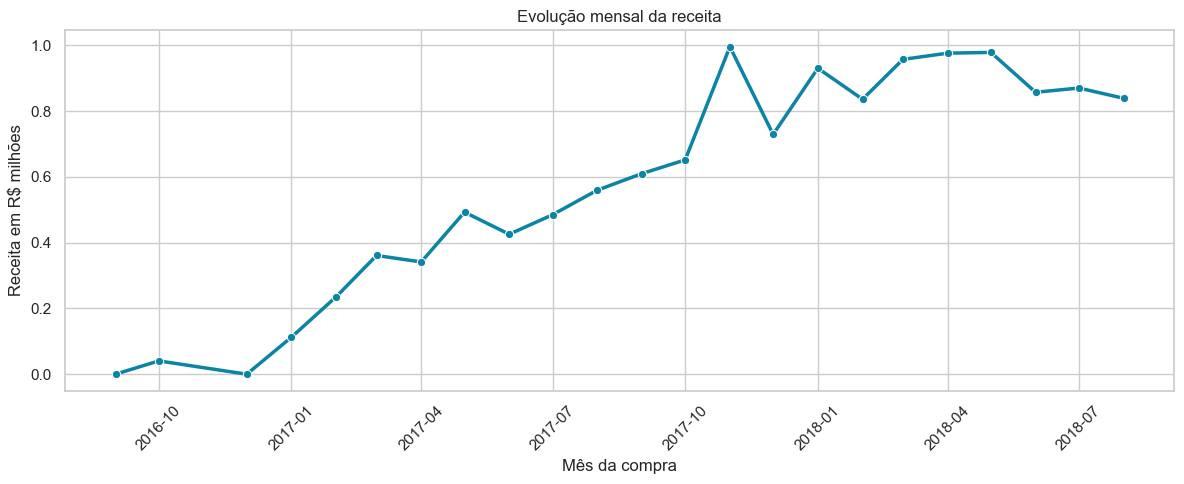

In [94]:
# Gráfico 1 - Evolução mensal da receita
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_plot_df,
    x="purchase_month",
    y="receita_milhoes",
    marker="o",
    linewidth=2.5,
    color="#0b84a5"
)
plt.title("Evolução mensal da receita")
plt.xlabel("Mês da compra")
plt.ylabel("Receita em R$ milhões")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grafico_evolucao_mensal_receita.png", dpi=200, bbox_inches="tight")
plt.show()

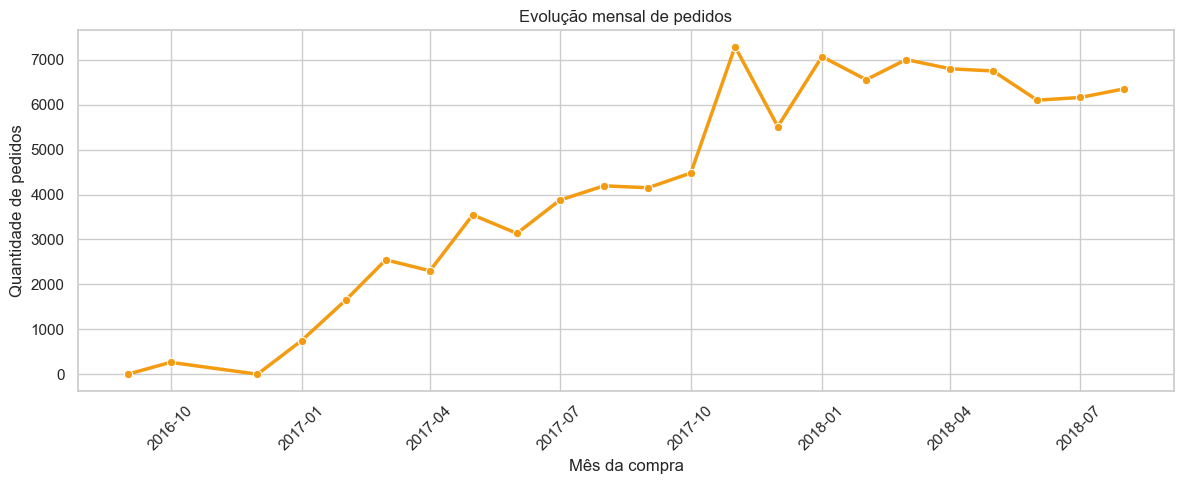

In [95]:
# Gráfico 2 - Evolução mensal de pedidos
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_plot_df,
    x="purchase_month",
    y="pedidos",
    marker="o",
    linewidth=2.5,
    color="#f39c12"
)
plt.title("Evolução mensal de pedidos")
plt.xlabel("Mês da compra")
plt.ylabel("Quantidade de pedidos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grafico_evolucao_mensal_pedidos.png", dpi=200, bbox_inches="tight")
plt.show()

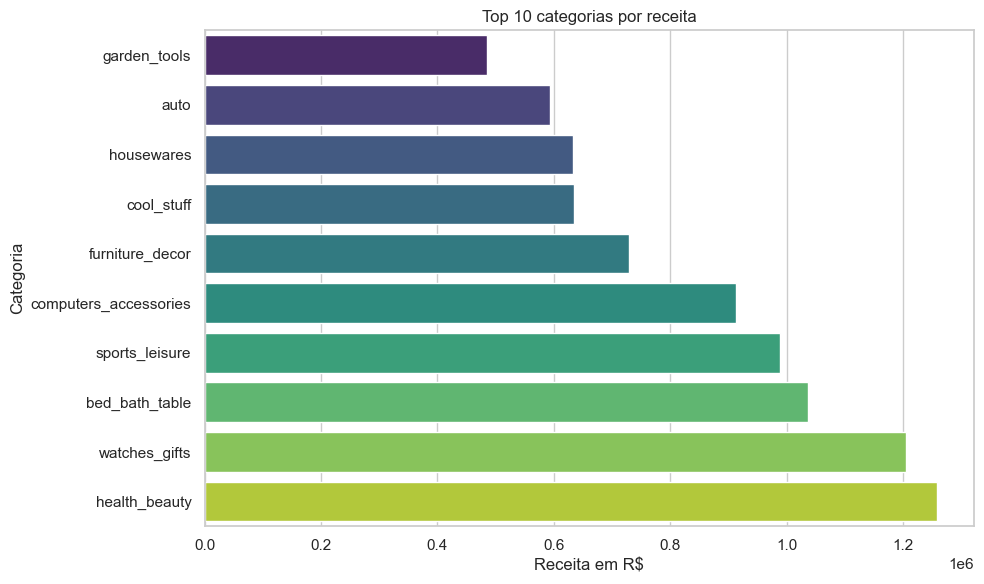

In [96]:
# Gráfico 3 - Top 10 categorias por receita
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_plot_df,
    y="product_category_name_english",
    x="receita",
    hue="product_category_name_english",
    dodge=False,
    palette="viridis",
    legend=False
)
plt.title("Top 10 categorias por receita")
plt.xlabel("Receita em R$")
plt.ylabel("Categoria")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grafico_top_categorias_receita.png", dpi=200, bbox_inches="tight")
plt.show()

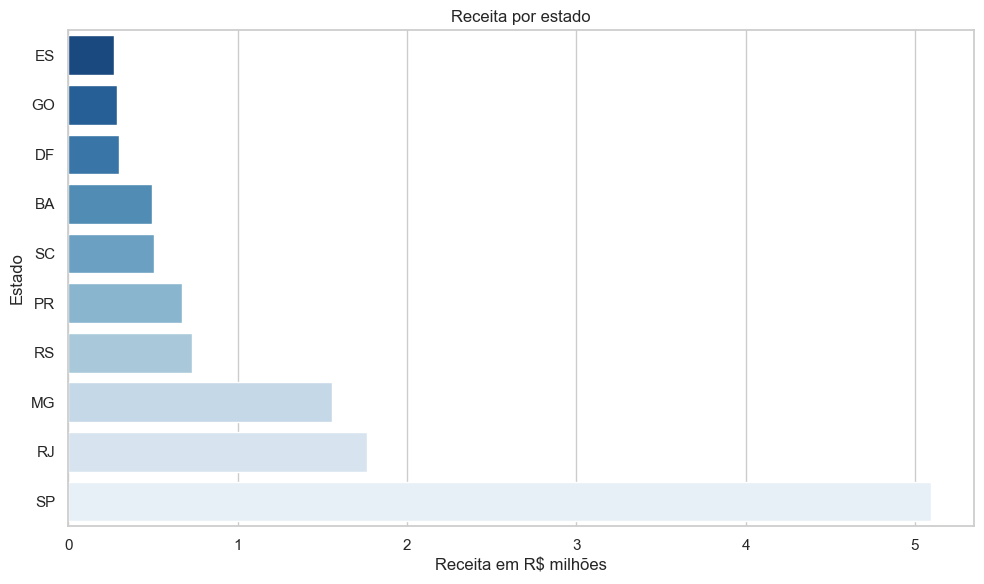

In [97]:
# Gráfico 4 - Receita por estado
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_estados_plot_df,
    y="customer_state",
    x="receita_milhoes",
    hue="customer_state",
    dodge=False,
    palette="Blues_r",
    legend=False
)
plt.title("Receita por estado")
plt.xlabel("Receita em R$ milhões")
plt.ylabel("Estado")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grafico_receita_por_estado.png", dpi=200, bbox_inches="tight")
plt.show()

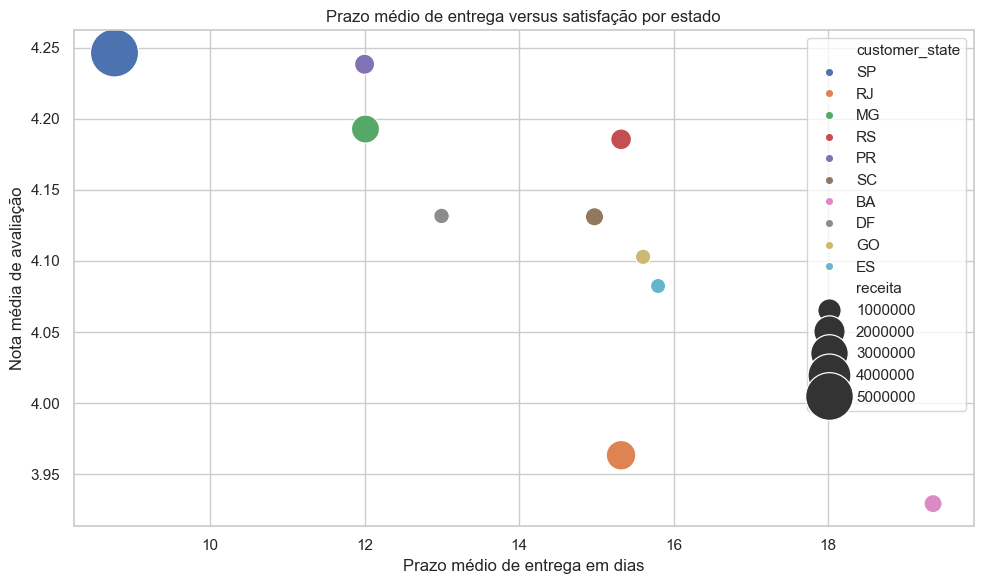

In [98]:
# Gráfico 5 - Prazo médio versus satisfação por estado
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=top_estados_receita_df,
    x="prazo_medio",
    y="nota_media",
    size="receita",
    hue="customer_state",
    sizes=(120, 1200)
)
plt.title("Prazo médio de entrega versus satisfação por estado")
plt.xlabel("Prazo médio de entrega em dias")
plt.ylabel("Nota média de avaliação")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grafico_prazo_vs_satisfacao_estado.png", dpi=200, bbox_inches="tight")
plt.show()

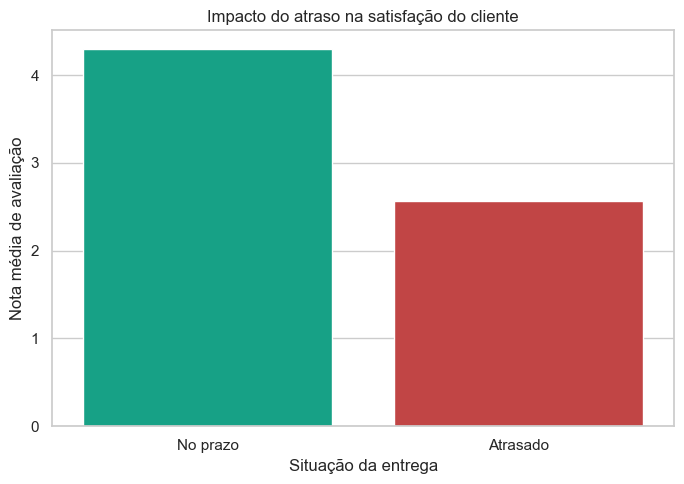

In [99]:
# Gráfico 6 - Impacto do atraso na satisfação
plt.figure(figsize=(7, 5))
sns.barplot(
    data=logistica_resumo_df,
    x="situacao_entrega",
    y="nota_media",
    hue="situacao_entrega",
    dodge=False,
    palette=["#00b894", "#d63031"],
    legend=False
)
plt.title("Impacto do atraso na satisfação do cliente")
plt.xlabel("Situação da entrega")
plt.ylabel("Nota média de avaliação")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grafico_impacto_atraso_satisfacao.png", dpi=200, bbox_inches="tight")
plt.show()

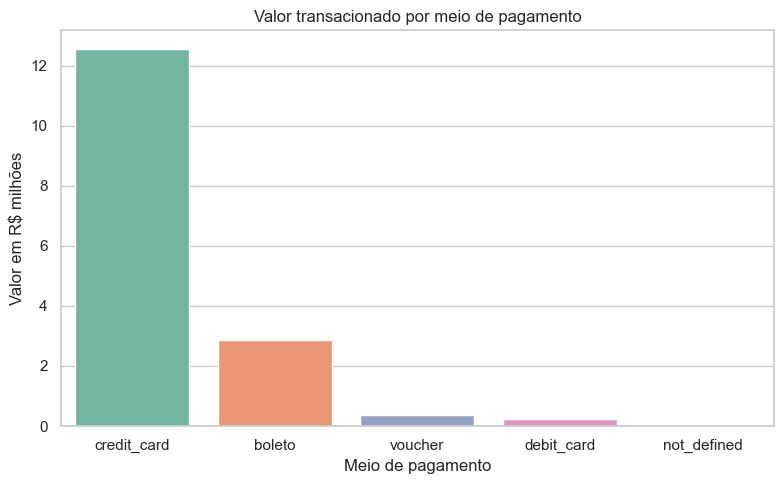

In [100]:
# Gráfico 7 - Valor transacionado por meio de pagamento
plt.figure(figsize=(8, 5))
sns.barplot(
    data=payment_plot_df,
    x="payment_type",
    y="valor_milhoes",
    hue="payment_type",
    dodge=False,
    palette="Set2",
    legend=False
)
plt.title("Valor transacionado por meio de pagamento")
plt.xlabel("Meio de pagamento")
plt.ylabel("Valor em R$ milhões")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "grafico_meios_pagamento.png", dpi=200, bbox_inches="tight")
plt.show()

O que esta etapa gera
Esses blocos salvam os principais gráficos do projeto em .png.

Leitura para estudo
Salvar gráficos com savefig() é fundamental quando você quer usar as imagens em Word, PowerPoint ou PDF.

Leitura para o relatório
Agora você terá, em uma pasta organizada, todos os gráficos principais da entrega executiva.



## 109. Gerando um arquivo texto com o resumo executivo

Agora vamos salvar um texto com a síntese final do relatório executivo.

In [101]:
texto_resumo_executivo = f"""
Relatório Executivo - Tech Challenge Olist

1. Principais indicadores
Pedidos entregues: {pedidos_entregues}
Receita total de itens: R$ {receita_total:,.2f}
Ticket médio: R$ {ticket_medio:,.2f}
Prazo médio de entrega: {prazo_medio:.2f} dias
Nota média de avaliação: {nota_media:.2f}
Pedidos atrasados: {pedidos_atrasados}
Taxa de atraso: {taxa_atraso * 100:.2f}%

2. Principais conclusões
A operação apresentou crescimento comercial relevante ao longo do período analisado.
A geração de valor está concentrada em categorias e estados específicos, com destaque para São Paulo.
O atraso logístico impacta fortemente a satisfação do cliente.
O cartão de crédito domina a jornada transacional.
A taxa de recompra é baixa, sugerindo oportunidade de avanço em retenção.

3. Mensagem final
A Olist já provou que consegue crescer. O próximo ciclo de geração de valor dependerá da capacidade de transformar eficiência operacional em fidelização, reputação e vantagem competitiva.
"""

with open(OUTPUT_DIR / "resumo_executivo_olist.txt", "w", encoding="utf-8") as file_out:
    file_out.write(texto_resumo_executivo)

print(texto_resumo_executivo)


Relatório Executivo - Tech Challenge Olist

1. Principais indicadores
Pedidos entregues: 96478
Receita total de itens: R$ 13,279,836.59
Ticket médio: R$ 136.90
Prazo médio de entrega: 12.56 dias
Nota média de avaliação: 4.16
Pedidos atrasados: 7865
Taxa de atraso: 8.15%

2. Principais conclusões
A operação apresentou crescimento comercial relevante ao longo do período analisado.
A geração de valor está concentrada em categorias e estados específicos, com destaque para São Paulo.
O atraso logístico impacta fortemente a satisfação do cliente.
O cartão de crédito domina a jornada transacional.
A taxa de recompra é baixa, sugerindo oportunidade de avanço em retenção.

3. Mensagem final
A Olist já provou que consegue crescer. O próximo ciclo de geração de valor dependerá da capacidade de transformar eficiência operacional em fidelização, reputação e vantagem competitiva.



O que esta etapa gera
Cria o arquivo resumo_executivo_olist.txt com uma síntese do trabalho.

Leitura para estudo
Esse tipo de exportação é muito útil porque conecta a análise quantitativa com o texto executivo final.

Leitura para o relatório
Esse arquivo pode servir como base para:

relatório escrito
apresentação
roteiro do vídeo

## 110. Listando os arquivos exportados

Por fim, vamos listar os arquivos salvos na pasta de saída para conferir se a organização final do projeto ficou correta.

In [102]:
arquivos_exportados = sorted([arquivo.name for arquivo in OUTPUT_DIR.iterdir()])
arquivos_exportados

['clientes_recorrencia.csv',
 'desempenho_categorias.csv',
 'desempenho_estados.csv',
 'grafico_evolucao_mensal_pedidos.png',
 'grafico_evolucao_mensal_receita.png',
 'grafico_impacto_atraso_satisfacao.png',
 'grafico_meios_pagamento.png',
 'grafico_prazo_vs_satisfacao_estado.png',
 'grafico_receita_por_estado.png',
 'grafico_top_categorias_receita.png',
 'kpi_resumo_executivo.csv',
 'kpis_mensais.csv',
 'meios_pagamento.csv',
 'perfil_cliente.csv',
 'relatorio_executivo_olist.txt',
 'resumo_executivo_olist.txt',
 'resumo_logistica.csv',
 'resumo_recorrencia.csv',
 'top_categorias.csv']

O que esta etapa gera
Lista todos os arquivos salvos na pasta final do projeto.

Leitura para estudo
É uma conferência final muito útil para validar se tudo foi exportado corretamente.

Leitura para o relatório
Essa etapa fecha o projeto com organização e controle.



## 111. Considerações finais da etapa de exportação

Com a conclusão desta etapa, o projeto passa a contar não apenas com o notebook analítico, mas também com um conjunto organizado de arquivos exportados.

Isso é importante porque amplia o reaproveitamento do trabalho em diferentes formatos:
- relatório escrito
- apresentação executiva
- revisão dos resultados
- compartilhamento com colegas ou grupo

Do ponto de vista de projeto, esta etapa também fortalece a reprodutibilidade e a governança da análise.